# Memory and Forecasting Analysis (Pilot Data + Pre-Pilot Trial Data Combined)

#### Importing Necessary Packages

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

### Defining global variables

In [2]:
AR_MEAN = 500
REQUIRE_COMPLETE_FORECASTS = True
FORECAST_START_INDEX = 20
EXPECTED_FORECAST_TRIALS = 60

POST_SWITCH_POSITIONS = [0, 1] # Regression (1) requires within-train positions 0 and 1
INCLUDE_PT_MAIN_EFFECT = False # Inclusion/exclusion of participant main effect in regression (2)
DISTRACTOR_ACCURACY_MIN = 0.60  # Primary analysis: exclude participants below this distractor-task accuracy
MODAL_FORECAST_SHARE_MAX = 0.80  # Primary analysis: exclude participants whose single most common forecast exceeds this share

OUTLIER_MODIFIED_Z_THRESHOLD = 3.5  # Robustness check: a forecast is an outlier if its error's per-participant modified z-score (MAD-based) exceeds this in absolute value
MEAN_ABS_ERROR_MAX = 30  # Robustness check: exclude participants whose mean absolute error (on non-outlier trains) exceeds this


### Defining data importation and plot exportation paths

Combines the 40-participant Prolific pilot with the 10-participant psiTurk trial run that preceded it. The two cohorts used separate stimuli files (`assignments.json` for the trial, `assignments_pilot.json` for the pilot), both with their own slot numbering starting at 0 -- so the trial cohort's `assignment_slot` values are left alone and the pilot cohort's are offset by `PILOT_SLOT_OFFSET` before the two are combined, so a merge on `assignment_slot` can never conflate a trial-cohort series with a pilot-cohort one that happens to share a raw slot number.

In [3]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PILOT_SLOT_OFFSET = 1000  # pilot has 40 slots (0-39); trial has 300 (0-299) -- offset keeps them disjoint

TRIAL_DATA_PATH = ROOT / "db_exports" / "trialdata_expanded.csv"
TRIAL_ASSIGNMENTS_PATH = ROOT / "static" / "data" / "assignments_v1.json"  # codeversion 0.0.1 ran against v1, not the later rho-conditioned assignments.json

PILOT_DATA_PATH = ROOT / "Pilot_Data" / "pilot.csv"
PILOT_ASSIGNMENTS_PATH = ROOT / "static" / "data" / "assignments_pilot.json"


def load_assignments(path):
    with open(path, "r", encoding="utf-8") as f:
        assignments = json.load(f)
    if isinstance(assignments, dict) and "assignments" in assignments:
        assignments = assignments["assignments"]
    return assignments


trial_df = pd.read_csv(TRIAL_DATA_PATH, low_memory=False)
trial_df["cohort"] = "trial"

pilot_df = pd.read_csv(PILOT_DATA_PATH, low_memory=False)
pilot_df["cohort"] = "pilot"
pilot_df["assignment_slot"] = pd.to_numeric(pilot_df["assignment_slot"], errors="coerce") + PILOT_SLOT_OFFSET

df = pd.concat([trial_df, pilot_df], ignore_index=True, sort=False)

trial_assignments = load_assignments(TRIAL_ASSIGNMENTS_PATH)
for a in trial_assignments:
    a["cohort"] = "trial"

pilot_assignments = load_assignments(PILOT_ASSIGNMENTS_PATH)
for a in pilot_assignments:
    a["cohort"] = "pilot"
    a["slot"] = a["slot"] + PILOT_SLOT_OFFSET

assignments = trial_assignments + pilot_assignments

print("Rows in exported data:", len(df))
print("  trial rows:", len(trial_df), "| pilot rows:", len(pilot_df))
print("Assignments:", len(assignments))
print("  trial assignments:", len(trial_assignments), "| pilot assignments:", len(pilot_assignments))
print("Unique participants (db_uniqueid):", df["db_uniqueid"].nunique())
print(df.groupby("cohort")["db_uniqueid"].nunique())

OUT_DIR = ROOT / "analysis_outputs" / "combined_participant_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = OUT_DIR / "combined_results_tables.pdf"

Rows in exported data: 19211
  trial rows: 3861 | pilot rows: 15350
Assignments: 340
  trial assignments: 300 | pilot assignments: 40
Unique participants (db_uniqueid): 57
cohort
pilot    47
trial    10
Name: db_uniqueid, dtype: int64


### Formatting table for regression results

In [4]:
def add_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def format_result_table(df, round_digits=4):
    out = df.copy()

    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].round(round_digits)
    return out

### Extract assignments and unique ids

In [5]:
# Participant/session column
if "db_uniqueid" in df.columns:
    participant_col = "db_uniqueid"
elif "uniqueId" in df.columns:
    participant_col = "uniqueId"
else:
    raise ValueError("Could not find participant id column.")

# Assignment column
if "assignment_slot" in df.columns:
    assignment_col = "assignment_slot"
elif "counterbalance" in df.columns:
    assignment_col = "counterbalance"
else:
    raise ValueError("Could not find assignment_slot or counterbalance column.")

participant_col, assignment_col

('db_uniqueid', 'assignment_slot')

### Extract strictly necessary data from assignments with complete data

In [6]:
def get_assignment_rho(assignment):
    if "rho" in assignment:
        return assignment["rho"]
    if "ar1" in assignment and "rho" in assignment["ar1"]:
        return assignment["ar1"]["rho"]
    raise ValueError("Could not find rho in assignment.")


def ols_slope(y_values, x_values):
    """Slope of an OLS regression of y on x with an intercept."""
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)

    x_centered = x - x.mean()
    denominator = (x_centered ** 2).sum()

    if denominator == 0:
        return np.nan

    return float((x_centered * (y - y.mean())).sum() / denominator)


def get_realized_rho(assignment, forecast_start_index=FORECAST_START_INDEX):
    """Sample AR(1) coefficient of the series this participant actually saw.

    The nominal rho is not the persistence a participant was exposed to. A
    single 80-point draw has a sample rho that scatters (SD ~0.10) and sits
    below nominal by roughly (1 + 3*rho)/T, which is ~0.06 here. Benchmarking
    forecasts against the nominal value therefore charges participants for a
    gap that is a property of the stimulus, not of their behaviour.

    Stimuli from experiment_code_version 3.0.0 onward are conditioned to remove
    this and store the value. Older files (assignments_v1.json, the psiTurk
    pilot) predate the field, so it is recomputed here instead -- which means
    this works against either stimulus file.

    Measured over the forecast rounds, matching the regression below:
    forecasting on round i, the participant has just seen values[i - 1].
    """
    stored = assignment.get("ar1", {}).get("realized_rho_forecast_window")
    if stored is not None:
        return float(stored)

    values = assignment["ar1"]["values"]
    x_values = values[forecast_start_index - 1:len(values) - 1]
    y_values = values[forecast_start_index:]

    return ols_slope(y_values, x_values)


def build_assignment_design(assignments):
    rows = []

    for assignment_index, assignment in enumerate(assignments):
        assignment_slot = assignment.get("slot", assignment.get("assignment_slot", assignment_index))

        values = assignment["ar1"]["values"]
        tasks = assignment["distraction"]["tasks"]
        assigned_rho = get_assignment_rho(assignment)
        realized_rho = get_realized_rho(assignment)

        train_id = -1
        last_task_type = None

        for round_index, task in enumerate(tasks):
            task_type = task["task_type"]

            if task_type != last_task_type:
                train_id += 1
                last_task_type = task_type

            rows.append({
                "assignment_slot": int(assignment_slot),
                "round_index": int(round_index),
                "task_type": task_type,
                "train_id": int(train_id),
                "assigned_rho": float(assigned_rho),

                # Persistence of this particular series, which is what the
                # participant could actually have learned from.
                "realized_rho": float(realized_rho),

                # The AR value revealed on this round.
                "x_next_true": values[round_index],

                # For a forecast on round i, the participant has just seen values[i - 1].
                "x_t": values[round_index - 1] if round_index >= 1 else np.nan,
                "x_t_minus_1": values[round_index - 2] if round_index >= 2 else np.nan,
                "x_t_minus_2": values[round_index - 3] if round_index >= 3 else np.nan,
            })

    design = pd.DataFrame(rows)

    # Train boundaries and train means.
    train_info = (
        design
        .groupby(["assignment_slot", "train_id", "task_type"], as_index=False)
        .agg(
            x_train_mean=("x_next_true", "mean"),
            train_start_round=("round_index", "min"),
            train_end_round=("round_index", "max"),
            train_length=("round_index", "count"),
        )
    )

    # Previous same-task train mean.
    train_info = train_info.sort_values(
        ["assignment_slot", "task_type", "train_start_round"]
    )

    train_info["x_match"] = (
        train_info
        .groupby(["assignment_slot", "task_type"])["x_train_mean"]
        .shift(1)
    )

    train_info["matched_train_id"] = (
        train_info
        .groupby(["assignment_slot", "task_type"])["train_id"]
        .shift(1)
    )

    design = design.merge(
        train_info[
            [
                "assignment_slot",
                "train_id",
                "x_train_mean",
                "x_match",
                "matched_train_id",
                "train_start_round",
                "train_end_round",
                "train_length",
            ]
        ],
        on=["assignment_slot", "train_id"],
        how="left"
    )

    # p_t: within-train position, 0 at the switch.
    design["p_t"] = design["round_index"] - design["train_start_round"]

    return design


assignment_design = build_assignment_design(assignments)

# How far the stimuli actually sit from their nominal persistence. Near zero
# for conditioned stimuli; ~-0.06 with wide scatter for the older files.
_rho_check = (
    assignment_design
    .groupby("assigned_rho")["realized_rho"]
    .agg(["mean", "std", "min", "max"])
)
print("Realized rho by nominal rho:")
print(_rho_check.round(4))

assignment_design.head()

Realized rho by nominal rho:
                mean     std     min     max
assigned_rho                                
0.6           0.5512  0.1116  0.1599  0.7912
0.7           0.6418  0.0999  0.1584  0.8663


,assignment_slot,round_index,task_type,train_id,assigned_rho,realized_rho,x_next_true,x_t,x_t_minus_1,x_t_minus_2,x_train_mean,x_match,matched_train_id,train_start_round,train_end_round,train_length,p_t
0,0,0,animacy,0,0.6,0.49555,500,NaN,NaN,NaN,488.500000,NaN,NaN,0,3,4,0
1,0,1,animacy,0,0.6,0.49555,512,500.0,NaN,NaN,488.500000,NaN,NaN,0,3,4,1
2,0,2,animacy,0,0.6,0.49555,483,512.0,500.0,NaN,488.500000,NaN,NaN,0,3,4,2
3,0,3,animacy,0,0.6,0.49555,459,483.0,512.0,500.0,488.500000,NaN,NaN,0,3,4,3
4,0,4,size,1,0.6,0.49555,489,459.0,483.0,512.0,474.333333,NaN,NaN,4,6,3,0


### Clean up data and create dataframe for analysis

In [7]:
forecast_rows = df[df["phase"] == "forecast"].copy()

forecast_rows["round_index"] = pd.to_numeric(
    forecast_rows["round_index"], errors="coerce"
)

forecast_rows["forecast_value"] = pd.to_numeric(
    forecast_rows["forecast_value"], errors="coerce"
)

forecast_rows[assignment_col] = pd.to_numeric(
    forecast_rows[assignment_col], errors="coerce"
)

forecast_rows = forecast_rows.dropna(
    subset=[participant_col, assignment_col, "round_index", "forecast_value"]
).copy()

forecast_rows["assignment_slot"] = forecast_rows[assignment_col].astype(int)
forecast_rows["round_index"] = forecast_rows["round_index"].astype(int)

forecast_small = forecast_rows[
    [
        participant_col,
        "assignment_slot",
        "round_index",
        "forecast_value",
    ]
].copy()

# Avoid duplicate forecast rows if repeated debug runs created duplicates.
forecast_small = (
    forecast_small
    .sort_values([participant_col, "assignment_slot", "round_index"])
    .drop_duplicates(
        subset=[participant_col, "assignment_slot", "round_index"],
        keep="last"
    )
)

analysis_df = forecast_small.merge(
    assignment_design,
    on=["assignment_slot", "round_index"],
    how="left"
)

analysis_df["rho_group"] = analysis_df["assigned_rho"].round(1)

analysis_df[
    [
        participant_col,
        "assignment_slot",
        "round_index",
        "rho_group",
        "task_type",
        "train_id",
        "p_t",
        "forecast_value",
        "x_t",
        "x_t_minus_1",
        "x_t_minus_2",
        "x_match",
    ]
].head(5)

,db_uniqueid,assignment_slot,round_index,rho_group,task_type,train_id,p_t,forecast_value,x_t,x_t_minus_1,x_t_minus_2,x_match
0,5ced49fa,1013,20,0.7,animacy,4,4,485.0,434.0,445.0,499.0,518.0
1,5ced49fa,1013,21,0.7,size,5,0,455.0,470.0,434.0,445.0,514.0
2,5ced49fa,1013,22,0.7,size,5,1,496.0,489.0,470.0,434.0,514.0
3,5ced49fa,1013,23,0.7,size,5,2,528.0,515.0,489.0,470.0,514.0
4,5ced49fa,1013,24,0.7,animacy,6,0,476.0,463.0,515.0,489.0,472.0


### Participant-level quality checks (primary-analysis exclusions)

In [8]:
def get_distractor_accuracy(df, participant_col, root=None):
    """
    Proportion of distractor (animacy/size) judgments matching the wordpool's
    ground truth, excluding words marked "ambiguous" (no definitive answer).
    """
    if root is None:
        root = ROOT

    wordpool_path = root / "static" / "data" / "wordpool_categories.csv"

    required_cols = {"phase", "word", "task_type", "distractor_response"}
    if not wordpool_path.exists() or not required_cols.issubset(df.columns):
        return pd.DataFrame({participant_col: [], "distractor_accuracy": []})

    wordpool = pd.read_csv(wordpool_path)

    distractor_rows = df[df["phase"] == "distractor_question"].copy()

    if "distractor_answered" in distractor_rows.columns:
        distractor_rows = distractor_rows[distractor_rows["distractor_answered"] == True]

    distractor_rows = distractor_rows.merge(wordpool, on="word", how="left")

    distractor_rows["ground_truth"] = np.where(
        distractor_rows["task_type"] == "animacy",
        distractor_rows["is_living"],
        distractor_rows["fits_shoebox"],
    )

    # Exclude words without a definitive right answer.
    distractor_rows = distractor_rows[distractor_rows["ground_truth"] != "ambiguous"]

    distractor_rows = distractor_rows.dropna(
        subset=[participant_col, "ground_truth", "distractor_response"]
    )

    distractor_rows["is_correct"] = (
        distractor_rows["distractor_response"] == distractor_rows["ground_truth"]
    )

    accuracy = (
        distractor_rows
        .groupby(participant_col, as_index=False)
        .agg(distractor_accuracy=("is_correct", "mean"))
    )

    return accuracy


def get_modal_forecast_share(analysis_df, participant_col):
    """
    Share of a participant's forecasts equal to their single most common value.
    A high share suggests the participant was not engaging with the task
    (e.g. entering the same number every round) rather than forecasting.
    """
    def _share(s):
        counts = s.value_counts()
        return counts.iloc[0] / len(s) if len(s) else np.nan

    return (
        analysis_df
        .dropna(subset=[participant_col, "forecast_value"])
        .groupby(participant_col)["forecast_value"]
        .apply(_share)
        .reset_index(name="modal_forecast_share")
    )


participant_trial_counts = (
    analysis_df
    .dropna(subset=[participant_col])
    .groupby(participant_col)
    .size()
    .reset_index(name="n_forecast_trials")
)

participant_quality = (
    participant_trial_counts
    .merge(get_distractor_accuracy(df, participant_col), on=participant_col, how="left")
    .merge(get_modal_forecast_share(analysis_df, participant_col), on=participant_col, how="left")
)

participant_quality["has_complete_data"] = (
    participant_quality["n_forecast_trials"] == EXPECTED_FORECAST_TRIALS
)

participant_quality["low_distractor_accuracy"] = (
    participant_quality["distractor_accuracy"] < DISTRACTOR_ACCURACY_MIN
)

participant_quality["high_modal_forecast_share"] = (
    participant_quality["modal_forecast_share"] > MODAL_FORECAST_SHARE_MAX
)

participant_quality["excluded_primary"] = (
    (~participant_quality["has_complete_data"])
    | participant_quality["low_distractor_accuracy"].fillna(False)
    | participant_quality["high_modal_forecast_share"].fillna(False)
)

excluded_primary_participants = set(
    participant_quality.loc[participant_quality["excluded_primary"], participant_col]
)

print(f"Participants with any forecast data: {len(participant_quality)}")
print(f"  incomplete data (!= {EXPECTED_FORECAST_TRIALS} forecast trials): {(~participant_quality['has_complete_data']).sum()}")
print(f"  distractor accuracy < {DISTRACTOR_ACCURACY_MIN:.0%}: {int(participant_quality['low_distractor_accuracy'].sum())}")
print(f"  modal forecast share > {MODAL_FORECAST_SHARE_MAX:.0%}: {int(participant_quality['high_modal_forecast_share'].sum())}")
print(f"  excluded overall: {len(excluded_primary_participants)}")
print(f"  remaining for primary analysis: {participant_quality[participant_col].nunique() - len(excluded_primary_participants)}")

analysis_df_primary = analysis_df[
    ~analysis_df[participant_col].isin(excluded_primary_participants)
].copy()

participant_quality.head()

Participants with any forecast data: 50
  incomplete data (!= 60 forecast trials): 2
  distractor accuracy < 60%: 1
  modal forecast share > 80%: 0
  excluded overall: 3
  remaining for primary analysis: 47


,db_uniqueid,n_forecast_trials,distractor_accuracy,modal_forecast_share,has_complete_data,low_distractor_accuracy,high_modal_forecast_share,excluded_primary
0,5ced49fa,60,0.966805,0.066667,True,False,False,False
1,e0e9a877,3,0.950820,0.666667,False,False,False,True
2,404f499c,60,0.901961,0.166667,True,False,False,False
3,bac610f2,60,0.857143,0.183333,True,False,False,False
4,b80c5bf6,60,0.809302,0.133333,True,False,False,False


#### QC case study: longest-duration participant

One participant's session lasted 76 minutes -- by far the longest in the pilot (mean is ~21 minutes, next-longest is ~28). That duration alone made them worth checking individually: was this a distracted/afk session that happened to finish before the 90-minute abandonment cutoff, or a genuine (if slow) completion? Their per-participant quality metrics, computed the same way as everyone else's, answer that directly below.

In [9]:
# Prolific PID <redacted>, slot 21, flagged for having the
# longest session (76.1 min) of any participant in the pilot.
qc_case_study_uid = "<redacted>8e358084"

_case_row = participant_quality[participant_quality[participant_col] == qc_case_study_uid].iloc[0]

_case_time = df.loc[
    df[participant_col] == qc_case_study_uid, ["db_begin_time", "db_end_time"]
].drop_duplicates().iloc[0]

_case_duration_min = (
    pd.to_datetime(_case_time["db_end_time"]) - pd.to_datetime(_case_time["db_begin_time"])
).total_seconds() / 60

_case_forecasts = analysis_df_primary[analysis_df_primary[participant_col] == qc_case_study_uid]
_case_mae = (_case_forecasts["forecast_value"] - _case_forecasts["x_next_true"]).abs().mean()

print(f"Participant {qc_case_study_uid} (Prolific PID <redacted>, slot 21)")
print(f"  completion time: {_case_duration_min:.1f} min (pilot mean ~21 min; longest session in the pilot)")
print(f"  forecast trials: {int(_case_row['n_forecast_trials'])} / {EXPECTED_FORECAST_TRIALS}")
print(f"  distractor accuracy: {_case_row['distractor_accuracy']:.0%} (primary-analysis floor: {DISTRACTOR_ACCURACY_MIN:.0%})")
print(f"  modal forecast share: {_case_row['modal_forecast_share']:.0%} (primary-analysis ceiling: {MODAL_FORECAST_SHARE_MAX:.0%})")
print(f"  mean abs forecast error: {_case_mae:.1f} (robustness-check ceiling: {MEAN_ABS_ERROR_MAX})")
print(f"  excluded from primary analysis: {bool(_case_row['excluded_primary'])}")
print()
print("Despite the unusually long session, this participant's data clears every")
print("quality threshold and is retained in both the primary analysis and the")
print("robustness check.")

Participant <redacted>8e358084 (Prolific PID <redacted>, slot 21)
  completion time: 76.1 min (pilot mean ~21 min; longest session in the pilot)
  forecast trials: 60 / 60
  distractor accuracy: 91% (primary-analysis floor: 60%)
  modal forecast share: 10% (primary-analysis ceiling: 80%)
  mean abs forecast error: 19.5 (robustness-check ceiling: 30)
  excluded from primary analysis: False

Despite the unusually long session, this participant's data clears every
quality threshold and is retained in both the primary analysis and the
robustness check.


### Calculate persistence implied by participant forecasts

In [10]:
def compute_participant_persistence(base_df, participant_col, require_exact_trial_count=True):
    """
    Participant-level implied persistence (OLS slope of forecast on x_t).

    require_exact_trial_count=True matches the primary analysis: a participant
    must have exactly EXPECTED_FORECAST_TRIALS forecast rows in `base_df`.
    Set to False for the robustness check, where whole trains have already
    been removed from `base_df` and an exact count is no longer meaningful.
    """
    persistence_df = base_df.dropna(
        subset=[
            participant_col,
            "rho_group",
            "forecast_value",
            "x_t",
        ]
    ).copy()

    persistence_df["forecast_c"] = persistence_df["forecast_value"] - AR_MEAN
    persistence_df["x_t_c"] = persistence_df["x_t"] - AR_MEAN

    rows = []

    for participant_id, g in persistence_df.groupby(participant_col):
        g = g.copy()

        if require_exact_trial_count and REQUIRE_COMPLETE_FORECASTS and len(g) != EXPECTED_FORECAST_TRIALS:
            continue

        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue

        rho_value = rho_values[0]

        realized_rho_values = g["realized_rho"].dropna().unique()
        if len(realized_rho_values) != 1:
            continue

        realized_rho = realized_rho_values[0]

        if len(g) < 5:
            continue

        if g["x_t_c"].nunique() < 2:
            continue

        try:
            res = smf.ols(
                "forecast_c ~ x_t_c",
                data=g
            ).fit()

            implied_rho = res.params.get("x_t_c", np.nan)

            rows.append({
                "participant": participant_id,
                "assigned_rho": rho_value,
                "realized_rho": realized_rho,
                "implied_rho": implied_rho,

                # Overreaction is implied persistence in excess of the persistence
                # actually present in the series the participant saw. Benchmarking
                # against the nominal rho instead would score a participant who
                # learned their own series perfectly as under-reacting, purely
                # because of small-sample bias in the stimulus.
                "rho_excess": implied_rho - realized_rho,

                # The previous nominal-rho benchmark, kept so the two can be
                # compared and reported side by side.
                "rho_excess_vs_nominal": implied_rho - rho_value,

                "n_obs": int(res.nobs),
                "r_squared": res.rsquared,
            })

        except Exception as e:
            print(f"Could not estimate persistence for participant {participant_id}: {e}")

    return pd.DataFrame(rows)


participant_persistence = compute_participant_persistence(analysis_df_primary, participant_col)

participant_persistence.head()

,participant,assigned_rho,realized_rho,implied_rho,rho_excess,rho_excess_vs_nominal,n_obs,r_squared
0,5ced49fa,0.7,0.709796,0.690532,-0.019264,-0.009468,60,0.595267
1,404f499c,0.7,0.690975,0.676207,-0.014768,-0.023793,60,0.719038
2,bac610f2,0.6,0.597849,0.731533,0.133684,0.131533,60,0.493865
3,b80c5bf6,0.6,0.597849,0.244320,-0.353529,-0.355680,60,0.005094
4,6bc8310e,0.6,0.603302,1.073803,0.470501,0.473803,60,0.956831


### Test for baseline overreaction

In [11]:
def test_baseline_overreaction(participant_persistence_df):
    rows = []

    for rho_value, g in participant_persistence_df.groupby("assigned_rho"):
        excess = g["rho_excess"].dropna()
        excess_vs_nominal = g["rho_excess_vs_nominal"].dropna()

        test = stats.ttest_1samp(
            excess,
            popmean=0,
            alternative="greater"
        )

        # Same test against the nominal rho, so the effect of the benchmark is
        # visible rather than buried in a choice made upstream.
        test_vs_nominal = stats.ttest_1samp(
            excess_vs_nominal,
            popmean=0,
            alternative="greater"
        )

        rows.append({
            "assigned_rho": rho_value,
            "n_participants": len(excess),
            "mean_realized_rho": g["realized_rho"].mean(),
            "mean_implied_rho": g["implied_rho"].mean(),
            "median_implied_rho": g["implied_rho"].median(),
            "mean_rho_excess": excess.mean(),
            "median_rho_excess": excess.median(),
            "sd_rho_excess": excess.std(ddof=1),
            "t_stat": test.statistic,
            "p_value_implied_rho_greater_than_true_rho": test.pvalue,

            "mean_rho_excess_vs_nominal": excess_vs_nominal.mean(),
            "t_stat_vs_nominal": test_vs_nominal.statistic,
            "p_value_vs_nominal": test_vs_nominal.pvalue,
        })

    return pd.DataFrame(rows)


persistence_tests = test_baseline_overreaction(participant_persistence)

persistence_tests

,assigned_rho,n_participants,mean_realized_rho,mean_implied_rho,median_implied_rho,mean_rho_excess,median_rho_excess,sd_rho_excess,t_stat,p_value_implied_rho_greater_than_true_rho,mean_rho_excess_vs_nominal,t_stat_vs_nominal,p_value_vs_nominal
0,0.6,26,0.578110,0.692490,0.727148,0.114380,0.148671,0.386228,1.510050,0.071784,0.092490,1.213297,0.118178
1,0.7,21,0.695752,0.705625,0.676207,0.009872,-0.019264,0.474128,0.095417,0.462466,0.005625,0.054340,0.478602


### Prep data for regressions

In [12]:
def prepare_regression_df(analysis_df):
    out = analysis_df.dropna(
        subset=[
            participant_col,
            "rho_group",
            "forecast_value",
            "x_t",
            "x_t_minus_1",
            "x_match",
            "p_t",
        ]
    ).copy()

    out["forecast_c"] = out["forecast_value"] - AR_MEAN
    out["x_t_c"] = out["x_t"] - AR_MEAN
    out["x_t_minus_1_c"] = out["x_t_minus_1"] - AR_MEAN
    out["x_t_minus_2_c"] = out["x_t_minus_2"] - AR_MEAN
    out["x_match_c"] = out["x_match"] - AR_MEAN

    out["p_t"] = pd.to_numeric(out["p_t"], errors="coerce")
    out["p_t_x_match_c"] = out["p_t"] * out["x_match_c"]

    return out


reg_df = prepare_regression_df(analysis_df_primary)

reg_df[
    [
        participant_col,
        "rho_group",
        "round_index",
        "task_type",
        "train_id",
        "p_t",
        "forecast_c",
        "x_t_c",
        "x_t_minus_1_c",
        "x_t_minus_2_c",
        "x_match_c",
        "p_t_x_match_c",
    ]
].head()

,db_uniqueid,rho_group,round_index,task_type,train_id,p_t,forecast_c,x_t_c,x_t_minus_1_c,x_t_minus_2_c,x_match_c,p_t_x_match_c
0,5ced49fa,0.7,20,animacy,4,4,-15.0,-66.0,-55.0,-1.0,18.0,72.0
1,5ced49fa,0.7,21,size,5,0,-45.0,-30.0,-66.0,-55.0,14.0,0.0
2,5ced49fa,0.7,22,size,5,1,-4.0,-11.0,-30.0,-66.0,14.0,14.0
3,5ced49fa,0.7,23,size,5,2,28.0,15.0,-11.0,-30.0,14.0,28.0
4,5ced49fa,0.7,24,animacy,6,0,-24.0,-37.0,15.0,-11.0,-28.0,-0.0


### Post-switch forecast bias regression

In [13]:
def participant_level_simple_gamma_postswitch(reg_df, lag_spec, post_switch_positions=[0, 1]):
    """
    Estimate participant-level gamma using only post-switch trials.

    post_switch_positions = [0, 1] means:
        p_t = 0: first trial after the task switch
        p_t = 1: second trial after the task switch

    lag_spec = 2:
        forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c

    lag_spec = 3:
        forecast_c ~ x_t_c + x_t_minus_1_c + x_t_minus_2_c + x_match_c
    """

    if lag_spec == 2:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_match_c",
            "p_t",
        ]

        formula = "forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c"

    elif lag_spec == 3:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
            "x_match_c",
            "p_t",
        ]

        formula = "forecast_c ~ x_t_c + x_t_minus_1_c + x_t_minus_2_c + x_match_c"

    else:
        raise ValueError("lag_spec must be 2 or 3.")

    rows = []

    # Keep only post-switch positions
    temp = reg_df.copy()
    temp = temp[temp["p_t"].isin(post_switch_positions)].copy()
    temp = temp.dropna(subset=needed).copy()

    for participant_id, g in temp.groupby(participant_col):
        g = g.copy()

        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue

        rho_value = rho_values[0]

        # Fewer observations now because we only use p_t = 0 and p_t = 1
        if len(g) < 8:
            continue

        if g["x_match_c"].nunique() < 2:
            continue

        try:
            res = smf.ols(formula, data=g).fit()

            rows.append({
                "participant": participant_id,
                "assigned_rho": rho_value,
                "lag_spec": lag_spec,
                "post_switch_positions": str(post_switch_positions),
                "gamma": res.params.get("x_match_c", np.nan),
                "gamma_se": res.bse.get("x_match_c", np.nan),
                "n_obs": int(res.nobs),
                "r_squared": res.rsquared,
                "formula": formula,
            })

        except Exception as e:
            print(
                f"Could not estimate post-switch gamma for participant "
                f"{participant_id}, lag_spec={lag_spec}: {e}"
            )

    return pd.DataFrame(rows)

In [14]:
simple_gamma_postswitch_2 = participant_level_simple_gamma_postswitch(
    reg_df,
    lag_spec=2,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gamma_postswitch_3 = participant_level_simple_gamma_postswitch(
    reg_df,
    lag_spec=3,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gammas_postswitch = pd.concat(
    [simple_gamma_postswitch_2, simple_gamma_postswitch_3],
    ignore_index=True
)

simple_gammas_postswitch.head()


def test_postswitch_gamma_greater_than_zero(simple_gammas_postswitch):
    rows = []

    for (rho_value, lag_spec), g in simple_gammas_postswitch.groupby(["assigned_rho", "lag_spec"]):
        gamma_values = g["gamma"].dropna()

        test = stats.ttest_1samp(
            gamma_values,
            popmean=0,
            alternative="greater"
        )

        rows.append({
            "assigned_rho": rho_value,
            "lag_spec": lag_spec,
            "post_switch_positions": str(POST_SWITCH_POSITIONS),
            "n_participants": len(gamma_values),
            "mean_gamma": gamma_values.mean(),
            "median_gamma": gamma_values.median(),
            "sd_gamma": gamma_values.std(ddof=1),
            "t_stat": test.statistic,
            "p_value_gamma_greater_than_0": test.pvalue,
        })

    return pd.DataFrame(rows)


simple_gamma_postswitch_tests = test_postswitch_gamma_greater_than_zero(simple_gammas_postswitch)

In [15]:
def test_gamma_condition_comparison(simple_gammas_postswitch):
    rows = []

    for lag_spec, g in simple_gammas_postswitch.groupby("lag_spec"):
        gamma_06 = g[g["assigned_rho"].round(1) == 0.6]["gamma"].dropna()
        gamma_07 = g[g["assigned_rho"].round(1) == 0.7]["gamma"].dropna()

        test = stats.ttest_ind(
            gamma_07,
            gamma_06,
            equal_var=False,
            alternative="greater"
        )

        rows.append({
            "lag_spec": lag_spec,
            "post_switch_positions": str(POST_SWITCH_POSITIONS),
            "n_rho_06": len(gamma_06),
            "n_rho_07": len(gamma_07),
            "mean_gamma_rho_06": gamma_06.mean(),
            "mean_gamma_rho_07": gamma_07.mean(),
            "difference_07_minus_06": gamma_07.mean() - gamma_06.mean(),
            "sd_gamma_rho_06": gamma_06.std(ddof=1),
            "sd_gamma_rho_07": gamma_07.std(ddof=1),
            "welch_t_stat": test.statistic,
            "p_value_rho_07_greater_than_rho_06": test.pvalue,
        })

    return pd.DataFrame(rows)


gamma_condition_postswitch_tests = test_gamma_condition_comparison(simple_gammas_postswitch)

In [16]:
print("Post-switch x_match gamma > 0 tests, using only p_t = 0 and p_t = 1")
display(simple_gamma_postswitch_tests)

print("Post-switch gamma comparison: rho 0.7 > rho 0.6")
display(gamma_condition_postswitch_tests)

Post-switch x_match gamma > 0 tests, using only p_t = 0 and p_t = 1


,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,sd_gamma,t_stat,p_value_gamma_greater_than_0
0,0.6,2,"[0, 1]",26,0.071818,0.043720,0.445152,0.822647,0.209243
1,0.6,3,"[0, 1]",26,0.092356,0.067710,0.471514,0.998750,0.163743
2,0.7,2,"[0, 1]",21,0.585140,0.131207,2.501619,1.071885,0.148268
3,0.7,3,"[0, 1]",21,0.600031,0.045066,2.529360,1.087108,0.144959


Post-switch gamma comparison: rho 0.7 > rho 0.6


,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,sd_gamma_rho_06,sd_gamma_rho_07,welch_t_stat,p_value_rho_07_greater_than_rho_06
0,2,"[0, 1]",26,21,0.071818,0.585140,0.513321,0.445152,2.501619,0.928526,0.181836
1,3,"[0, 1]",26,21,0.092356,0.600031,0.507675,0.471514,2.529360,0.907139,0.187283


### Reinstatement decay across train position regression

In [17]:
def participant_level_interaction_gammas(reg_df, lag_spec, include_pt_main_effect=False):
    """
    lag_spec = 2:
        controls x_t and x_t_minus_1

    lag_spec = 3:
        controls x_t, x_t_minus_1, and x_t_minus_2

    include_pt_main_effect=False matches written equation.
    include_pt_main_effect=True controls for average within-train drift (just in case).
    """
    if lag_spec == 2:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_match_c",
            "p_t",
            "p_t_x_match_c",
        ]

        predictors = [
            "x_t_c",
            "x_t_minus_1_c",
        ]

    elif lag_spec == 3:
        needed = [
            "forecast_c",
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
            "x_match_c",
            "p_t",
            "p_t_x_match_c",
        ]

        predictors = [
            "x_t_c",
            "x_t_minus_1_c",
            "x_t_minus_2_c",
        ]

    else:
        raise ValueError("lag_spec must be 2 or 3.")

    if include_pt_main_effect:
        predictors = predictors + ["p_t"]

    predictors = predictors + ["x_match_c", "p_t_x_match_c"]

    formula = "forecast_c ~ " + " + ".join(predictors)

    rows = []

    for participant_id, g in reg_df.dropna(subset=needed).groupby(participant_col):
        g = g.copy()

        if REQUIRE_COMPLETE_FORECASTS and len(g) < 40:
            continue

        rho_values = g["rho_group"].dropna().unique()
        if len(rho_values) != 1:
            continue

        rho_value = rho_values[0]

        if len(g) < len(predictors) + 3:
            continue

        if g["x_match_c"].nunique() < 2:
            continue

        if g["p_t_x_match_c"].nunique() < 2:
            continue

        try:
            res = smf.ols(formula, data=g).fit()

            rows.append({
                "participant": participant_id,
                "assigned_rho": rho_value,
                "lag_spec": lag_spec,
                "include_pt_main_effect": include_pt_main_effect,
                "gamma_0": res.params.get("x_match_c", np.nan),
                "gamma_1": res.params.get("p_t_x_match_c", np.nan),
                "gamma_0_se": res.bse.get("x_match_c", np.nan),
                "gamma_1_se": res.bse.get("p_t_x_match_c", np.nan),
                "n_obs": int(res.nobs),
                "r_squared": res.rsquared,
                "formula": formula,
            })

        except Exception as e:
            print(
                f"Could not estimate interaction gammas for participant "
                f"{participant_id}, lag_spec={lag_spec}: {e}"
            )

    return pd.DataFrame(rows)

In [18]:
interaction_gamma_2 = participant_level_interaction_gammas(
    reg_df,
    lag_spec=2,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gamma_3 = participant_level_interaction_gammas(
    reg_df,
    lag_spec=3,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gammas = pd.concat(
    [interaction_gamma_2, interaction_gamma_3],
    ignore_index=True
)

interaction_gammas.head()

,participant,assigned_rho,lag_spec,include_pt_main_effect,gamma_0,gamma_1,gamma_0_se,gamma_1_se,n_obs,r_squared,formula
0,5ced49fa,0.7,2,False,0.094098,0.060376,0.127622,0.049545,60,0.685532,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
1,404f499c,0.7,2,False,0.190926,-0.056412,0.131676,0.055397,60,0.730020,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
2,bac610f2,0.6,2,False,0.487407,0.017362,0.217283,0.093758,60,0.589942,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
3,b80c5bf6,0.6,2,False,-1.897295,0.208096,1.055855,0.455604,60,0.104647,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...
4,6bc8310e,0.6,2,False,0.020281,0.008978,0.066136,0.025004,60,0.958099,forecast_c ~ x_t_c + x_t_minus_1_c + x_match_c...


In [19]:
def test_interaction_gammas(interaction_gammas):
    rows = []

    for (rho_value, lag_spec), g in interaction_gammas.groupby(["assigned_rho", "lag_spec"]):
        gamma_0_values = g["gamma_0"].dropna()
        gamma_1_values = g["gamma_1"].dropna()

        gamma_0_test = stats.ttest_1samp(
            gamma_0_values,
            popmean=0,
            alternative="greater"
        )

        gamma_1_test = stats.ttest_1samp(
            gamma_1_values,
            popmean=0,
            alternative="less"
        )

        rows.append({
            "assigned_rho": rho_value,
            "lag_spec": lag_spec,

            "n_participants_gamma_0": len(gamma_0_values),
            "mean_gamma_0": gamma_0_values.mean(),
            "median_gamma_0": gamma_0_values.median(),
            "sd_gamma_0": gamma_0_values.std(ddof=1),
            "t_gamma_0": gamma_0_test.statistic,
            "p_value_gamma_0_greater_than_0": gamma_0_test.pvalue,

            "n_participants_gamma_1": len(gamma_1_values),
            "mean_gamma_1": gamma_1_values.mean(),
            "median_gamma_1": gamma_1_values.median(),
            "sd_gamma_1": gamma_1_values.std(ddof=1),
            "t_gamma_1": gamma_1_test.statistic,
            "p_value_gamma_1_less_than_0": gamma_1_test.pvalue,
        })

    return pd.DataFrame(rows)


interaction_gamma_tests = test_interaction_gammas(interaction_gammas)

interaction_gamma_tests

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,median_gamma_0,sd_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,n_participants_gamma_1,mean_gamma_1,median_gamma_1,sd_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0
0,0.6,2,26,0.057451,-0.009717,0.552737,0.529988,0.300398,26,0.258930,0.011451,0.902553,1.462840,0.922015
1,0.6,3,26,0.070169,-0.012387,0.564683,0.633621,0.266041,26,0.256024,0.005329,0.900331,1.449993,0.920254
2,0.7,2,21,0.483353,0.125744,2.055178,1.077765,0.146983,21,-0.042720,0.004316,0.258297,-0.757913,0.228671
3,0.7,3,21,0.533487,0.129478,2.289194,1.067949,0.149132,21,-0.068929,0.009619,0.376580,-0.838792,0.205750


### Build plots for N most recent participants

In [20]:
# Plot every participant with complete forecast data (not just the most recent N).
NUMBER_OF_PLOTS = None

In [21]:
def estimate_slope_from_centered_ols(g, y_col, x_col="x_t", mean_value=500):
    """
    Estimate slope from:
        y - mean = alpha + slope * (x - mean) + error
    """
    temp = g[[x_col, y_col]].copy()
    temp[x_col] = pd.to_numeric(temp[x_col], errors="coerce")
    temp[y_col] = pd.to_numeric(temp[y_col], errors="coerce")
    temp = temp.dropna()

    if len(temp) < 5:
        return np.nan

    temp["x_c"] = temp[x_col] - mean_value
    temp["y_c"] = temp[y_col] - mean_value

    if temp["x_c"].nunique() < 2:
        return np.nan

    try:
        res = smf.ols("y_c ~ x_c", data=temp).fit()
        return res.params["x_c"]
    except Exception:
        return np.nan


def get_final_scores(df, participant_col):
    """
    Pull final cumulative score from forecast feedback rows.
    """
    score_rows = df[df["phase"] == "forecast_feedback_recitation"].copy()

    if "cumulative_score" not in score_rows.columns:
        return pd.DataFrame({
            participant_col: [],
            "final_score": []
        })

    score_rows["cumulative_score"] = pd.to_numeric(
        score_rows["cumulative_score"], errors="coerce"
    )

    final_scores = (
        score_rows
        .dropna(subset=[participant_col, "cumulative_score"])
        .groupby(participant_col, as_index=False)
        .agg(final_score=("cumulative_score", "max"))
    )

    return final_scores


def get_completion_times(df, participant_col):
    """
    Wall-clock completion time in minutes, from db_begin_time/db_end_time.
    """
    if "db_begin_time" not in df.columns or "db_end_time" not in df.columns:
        return pd.DataFrame({participant_col: [], "completion_time_min": []})

    time_rows = (
        df[[participant_col, "db_begin_time", "db_end_time"]]
        .dropna(subset=[participant_col])
        .drop_duplicates(subset=[participant_col])
        .copy()
    )

    time_rows["db_begin_time"] = pd.to_datetime(time_rows["db_begin_time"], errors="coerce")
    time_rows["db_end_time"] = pd.to_datetime(time_rows["db_end_time"], errors="coerce")

    time_rows["completion_time_min"] = (
        (time_rows["db_end_time"] - time_rows["db_begin_time"]).dt.total_seconds() / 60
    )

    return time_rows[[participant_col, "completion_time_min"]].dropna(subset=["completion_time_min"])


def get_recent_participants(df, participant_col, n=5):
    """
    Uses row order in the exported CSV as the notion of recency.
    The participants whose rows appear latest in df are treated as most recent.
    """
    temp = df.reset_index().rename(columns={"index": "_row_order"})

    recent = (
        temp
        .dropna(subset=[participant_col])
        .groupby(participant_col, as_index=False)
        .agg(last_row=("_row_order", "max"))
        .sort_values("last_row", ascending=False)
        .head(n)
    )

    return recent[participant_col].tolist()


def build_recent_plot_df_with_passive_values(analysis_df, assignment_design, df, participant_col):
    """
    Build plotting dataframe with:
      - all true AR(1) values, including passive observation phase
      - participant forecasts merged only where forecasts exist
    """

    # Participant -> assignment mapping, from observed forecast rows
    participant_assignments = (
        analysis_df
        .dropna(subset=[participant_col, "assignment_slot"])
        [[participant_col, "assignment_slot"]]
        .drop_duplicates()
        .copy()
    )

    participant_assignments["assignment_slot"] = pd.to_numeric(
        participant_assignments["assignment_slot"], errors="coerce"
    ).astype(int)

    # Full true-value sequence for each assignment
    true_values = assignment_design[
        [
            "assignment_slot",
            "round_index",
            "x_next_true",
            "x_t",
            "assigned_rho",
            "task_type",
            "train_id",
            "p_t",
        ]
    ].copy()

    for col in ["assignment_slot", "round_index", "x_next_true", "x_t", "assigned_rho", "p_t"]:
        true_values[col] = pd.to_numeric(true_values[col], errors="coerce")

    true_values["assignment_slot"] = true_values["assignment_slot"].astype(int)
    true_values["round_index"] = true_values["round_index"].astype(int)

    # Expand full true-value sequence to each participant's assignment
    full_plot_df = participant_assignments.merge(
        true_values,
        on="assignment_slot",
        how="left"
    )

    # Forecasts exist only for forecast trials
    forecasts = analysis_df[
        [
            participant_col,
            "assignment_slot",
            "round_index",
            "forecast_value",
        ]
    ].copy()

    for col in ["assignment_slot", "round_index", "forecast_value"]:
        forecasts[col] = pd.to_numeric(forecasts[col], errors="coerce")

    forecasts = forecasts.dropna(
        subset=[participant_col, "assignment_slot", "round_index", "forecast_value"]
    ).copy()

    forecasts["assignment_slot"] = forecasts["assignment_slot"].astype(int)
    forecasts["round_index"] = forecasts["round_index"].astype(int)

    forecasts = (
        forecasts
        .sort_values([participant_col, "assignment_slot", "round_index"])
        .drop_duplicates(
            subset=[participant_col, "assignment_slot", "round_index"],
            keep="last"
        )
    )

    # Merge forecasts onto the full true-value sequence
    full_plot_df = full_plot_df.merge(
        forecasts,
        on=[participant_col, "assignment_slot", "round_index"],
        how="left"
    )

    # Add final scores
    final_scores = get_final_scores(df, participant_col)

    full_plot_df = full_plot_df.merge(
        final_scores,
        on=participant_col,
        how="left"
    )

    # Add completion times
    completion_times = get_completion_times(df, participant_col)

    full_plot_df = full_plot_df.merge(
        completion_times,
        on=participant_col,
        how="left"
    )

    # Add distractor task accuracy and modal-forecast share (already computed
    # once, above, for the primary-analysis quality filters).
    full_plot_df = full_plot_df.merge(
        participant_quality[[participant_col, "distractor_accuracy", "modal_forecast_share"]],
        on=participant_col,
        how="left"
    )

    return full_plot_df

recent_plot_df = build_recent_plot_df_with_passive_values(
    analysis_df=analysis_df,
    assignment_design=assignment_design,
    df=df,
    participant_col=participant_col
)

recent_participants = get_recent_participants(
    df=df,
    participant_col=participant_col,
    n=df[participant_col].dropna().nunique()
)

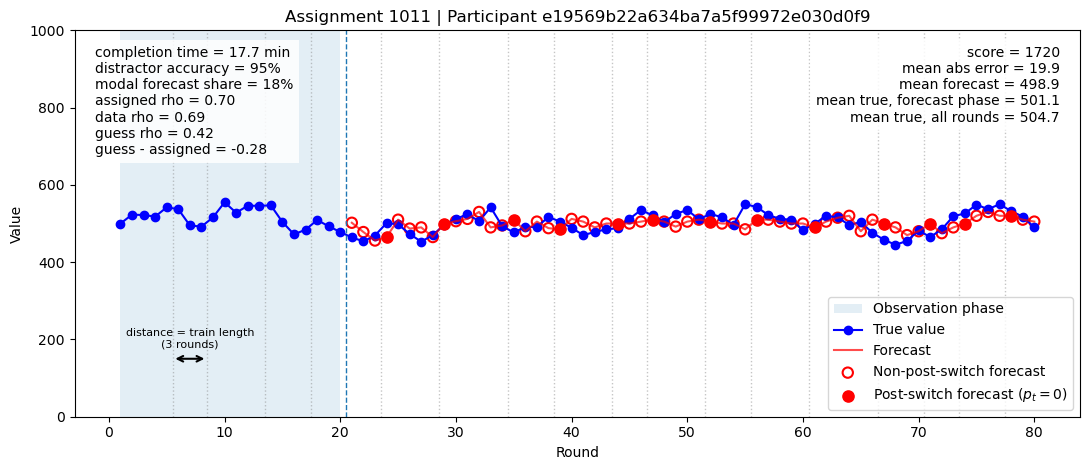

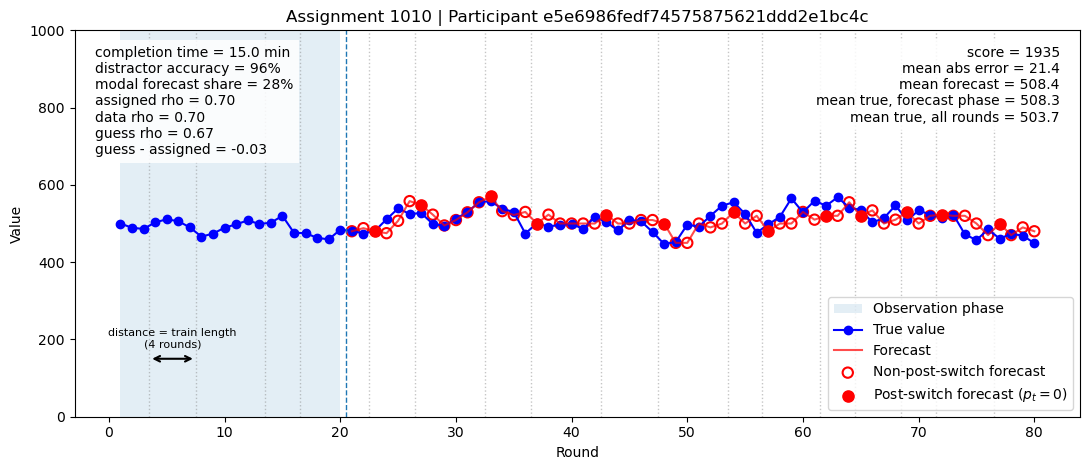

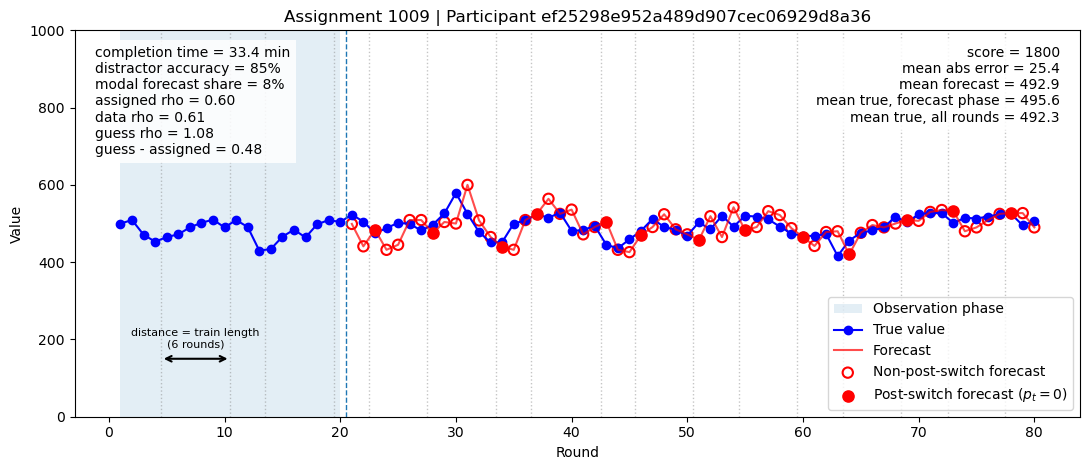

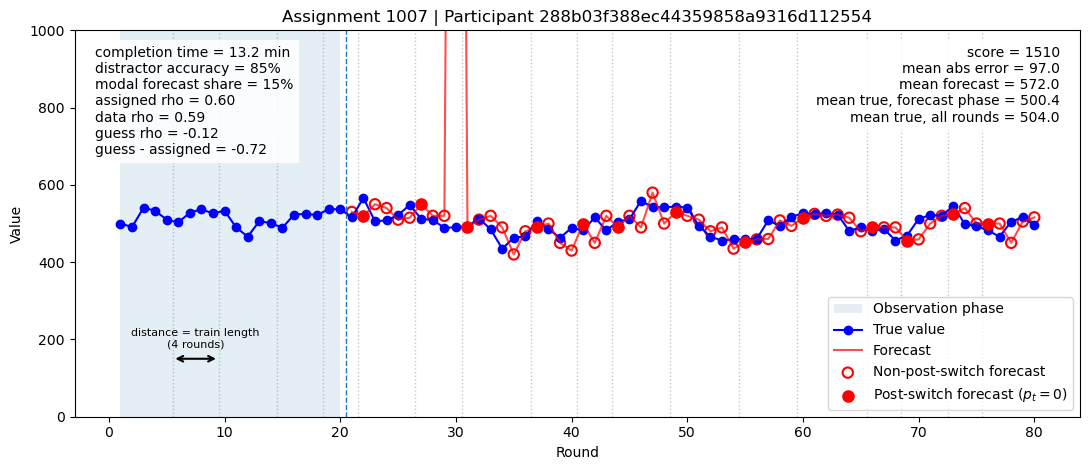

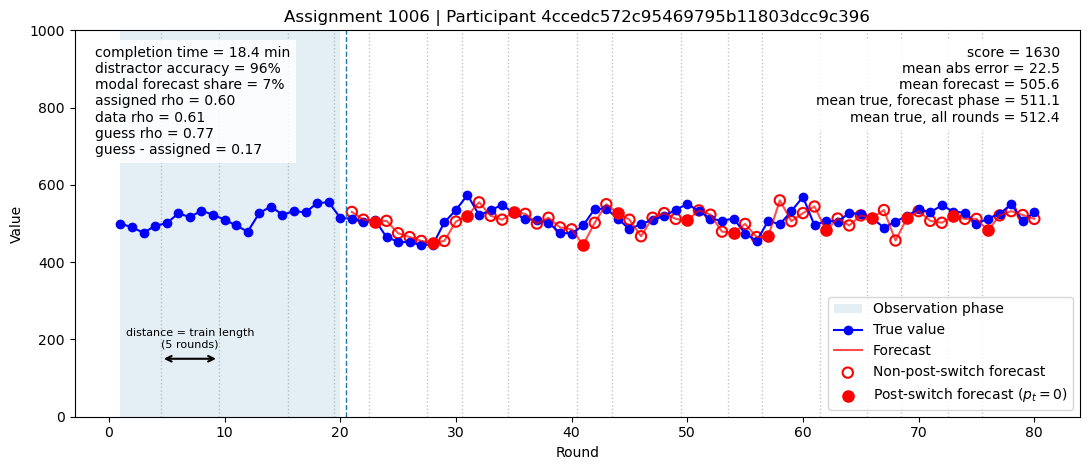

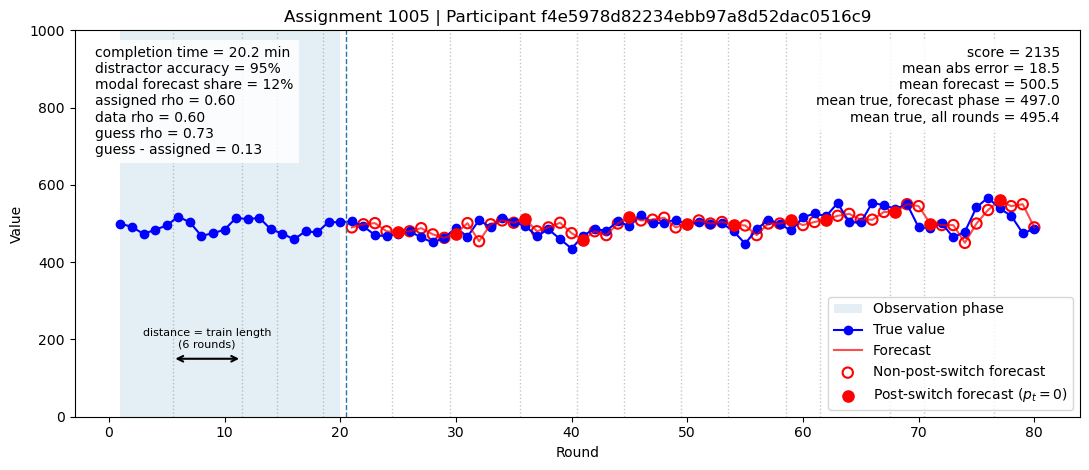

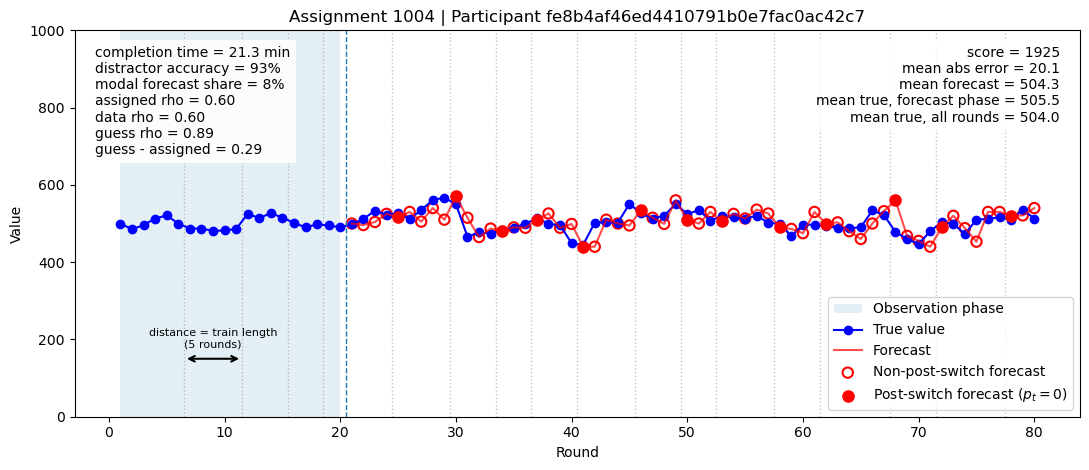

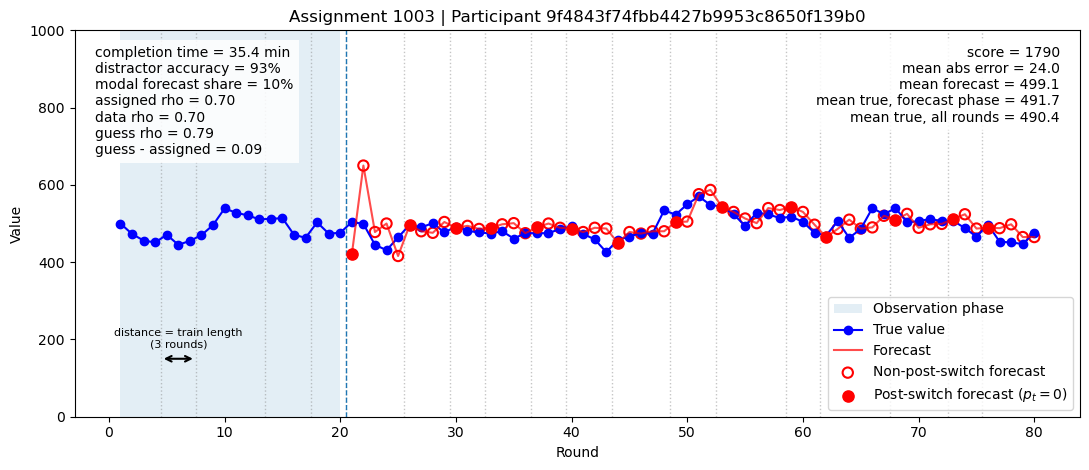

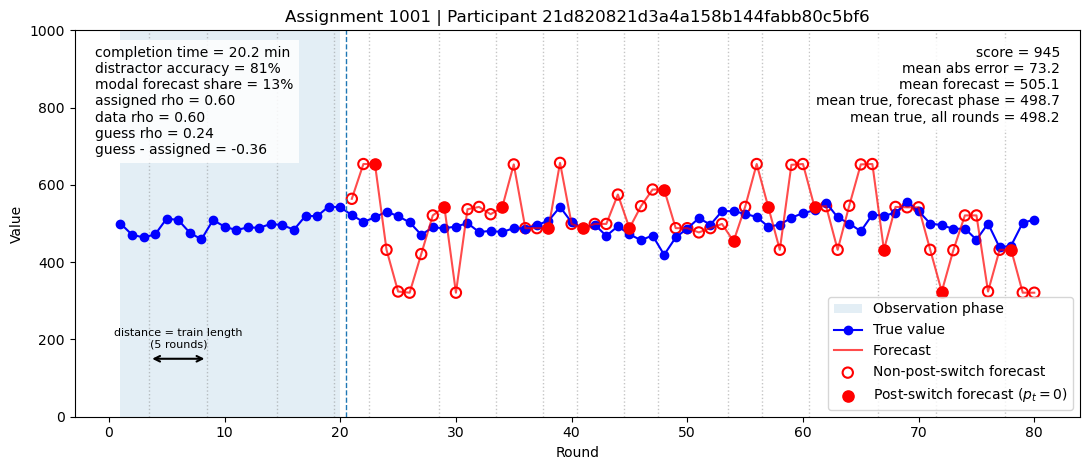

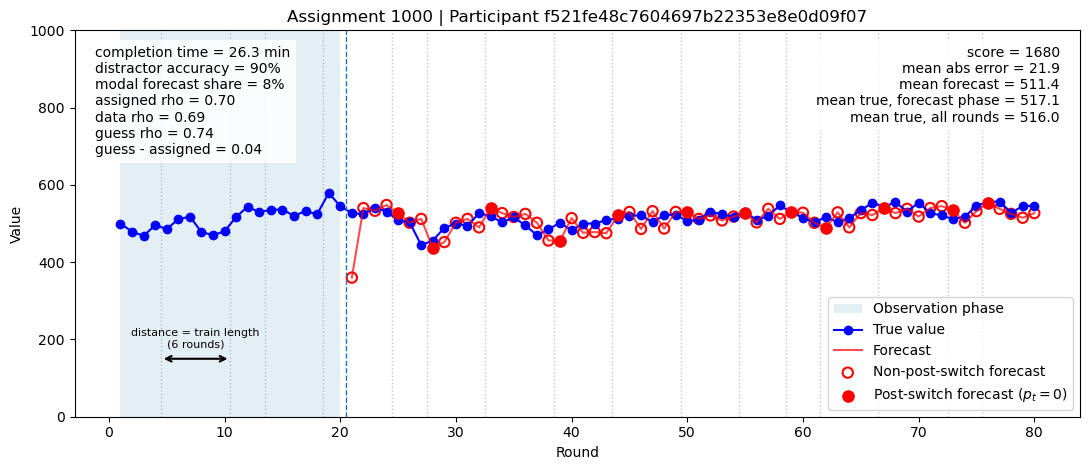

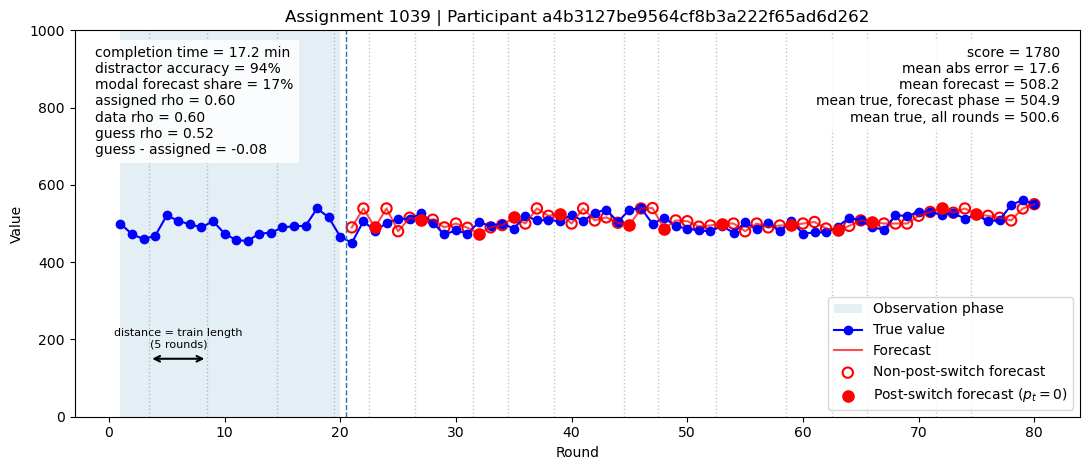

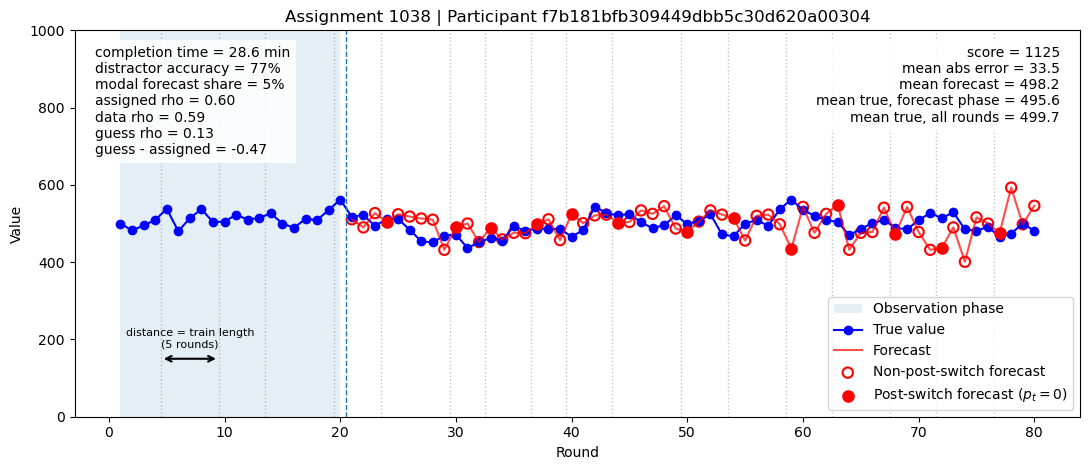

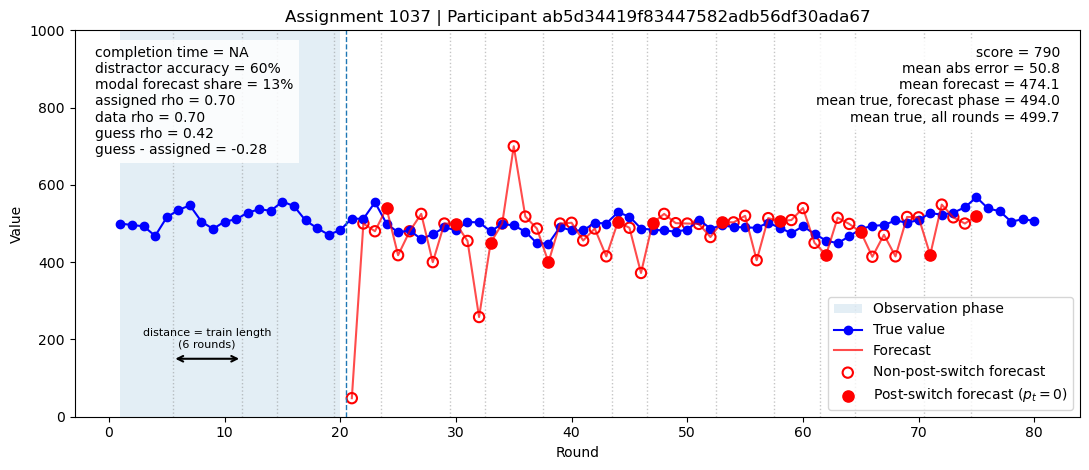

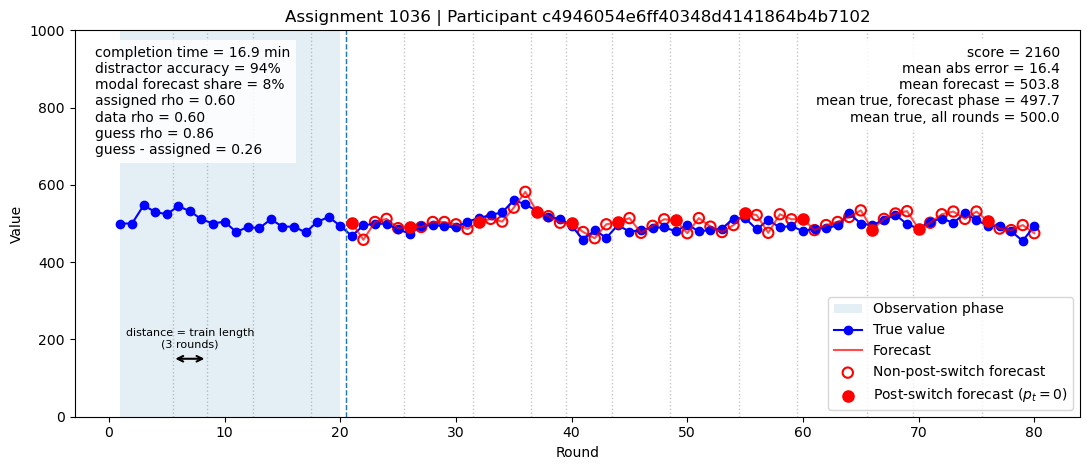

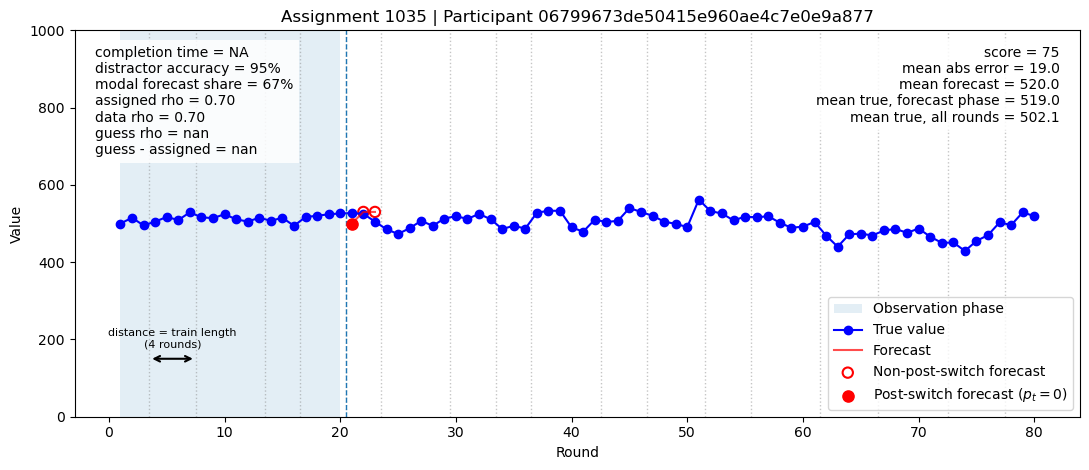

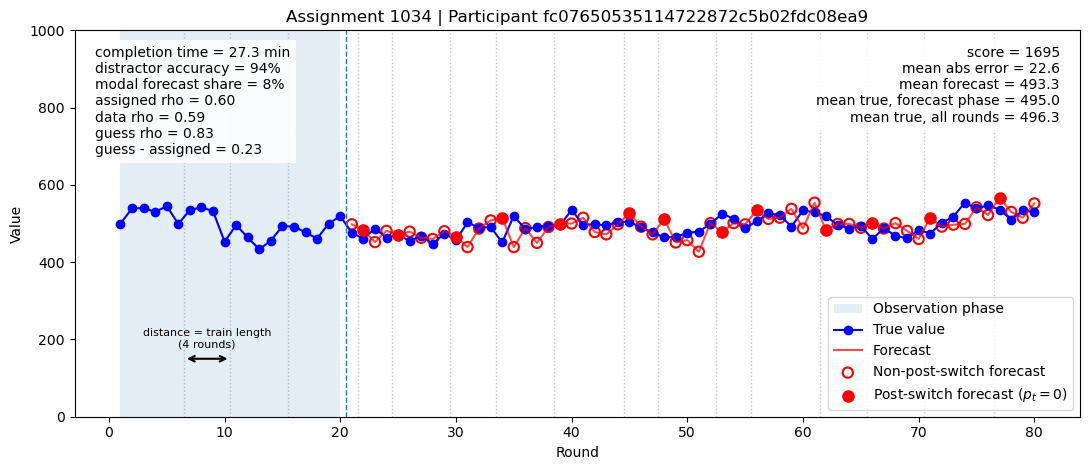

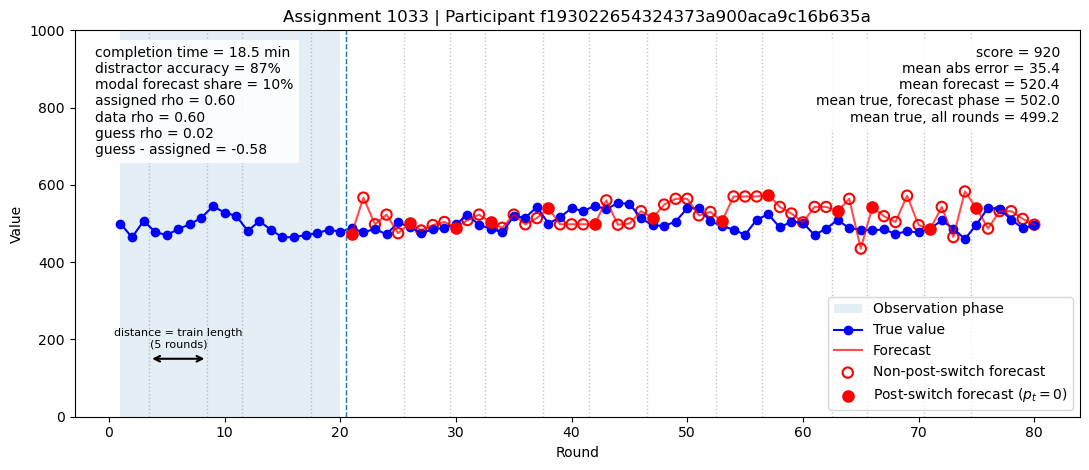

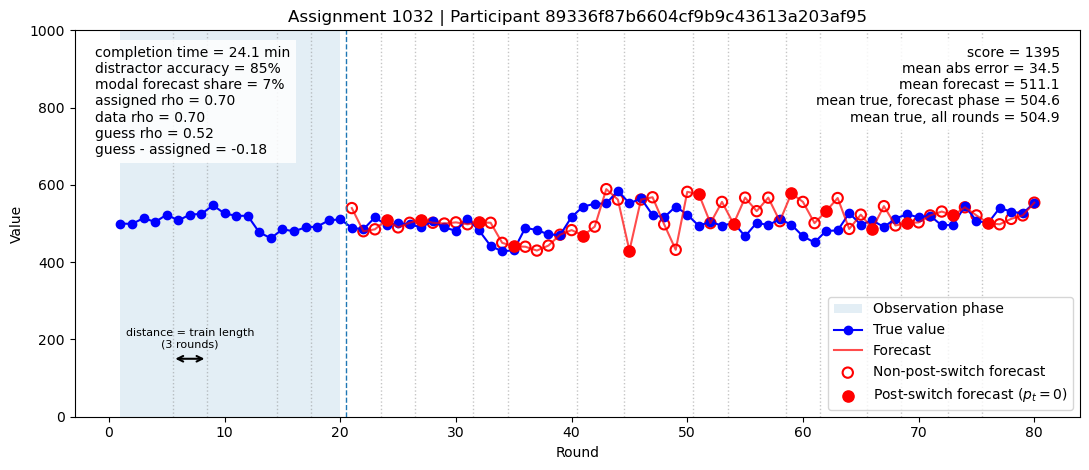

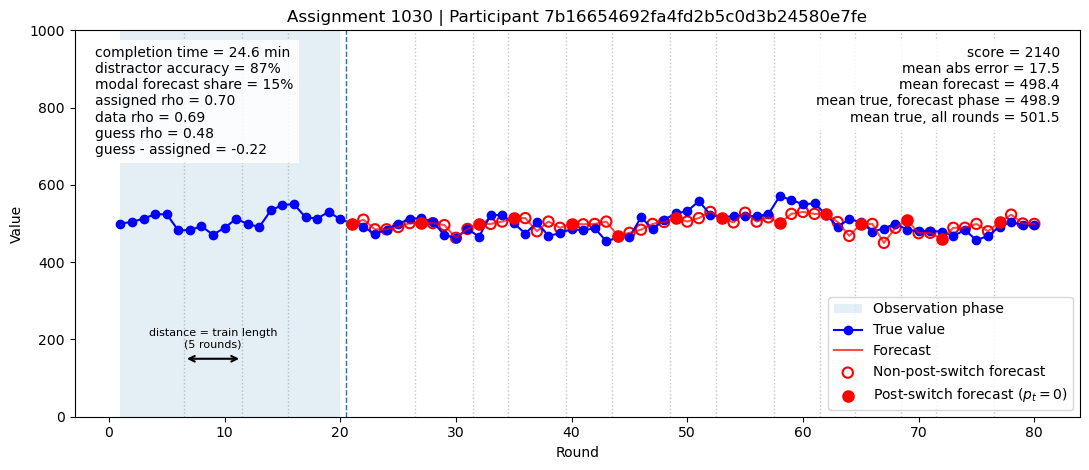

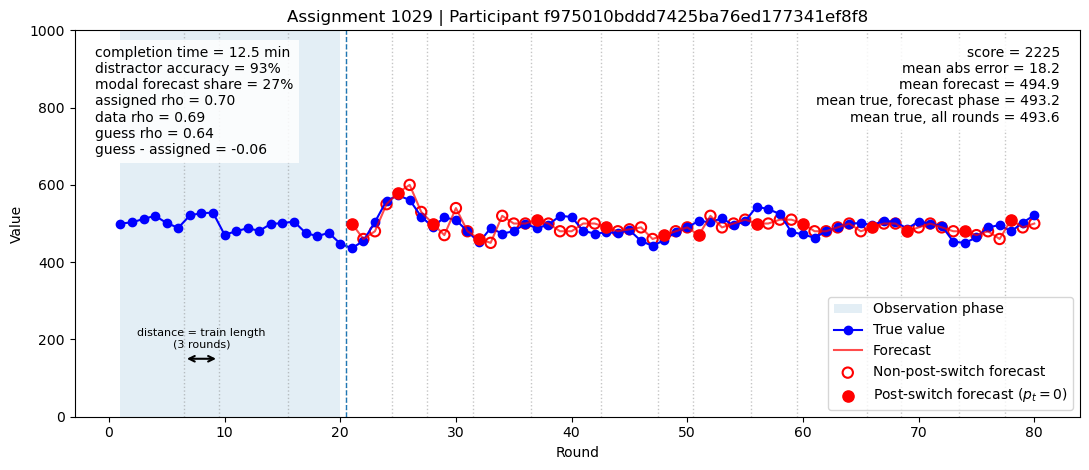

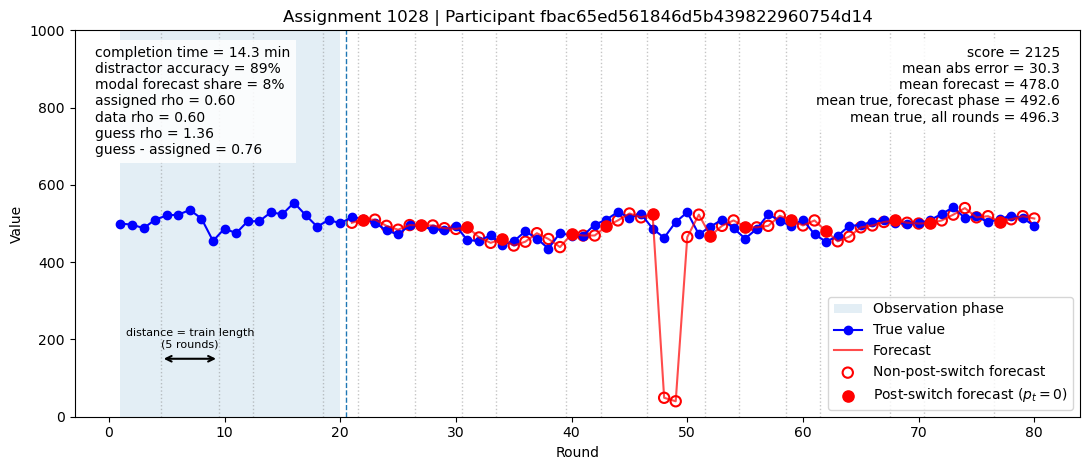

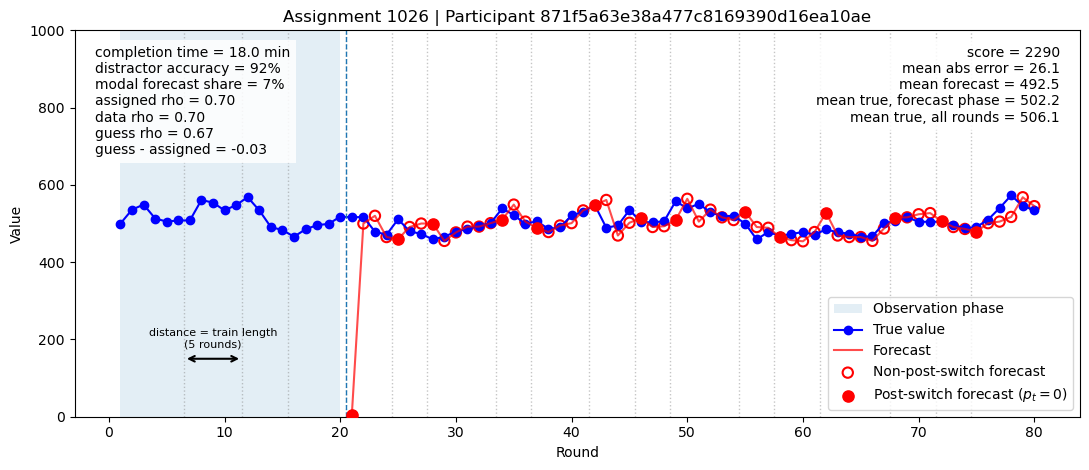

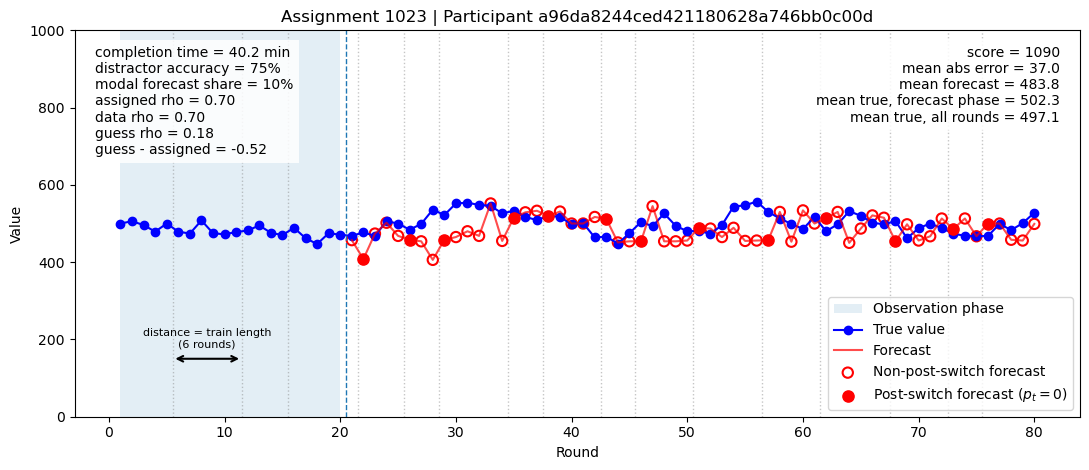

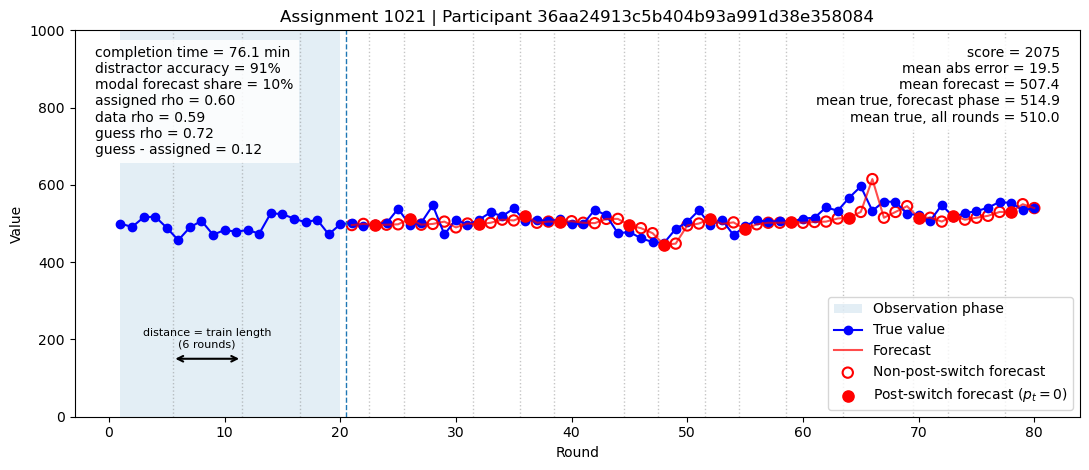

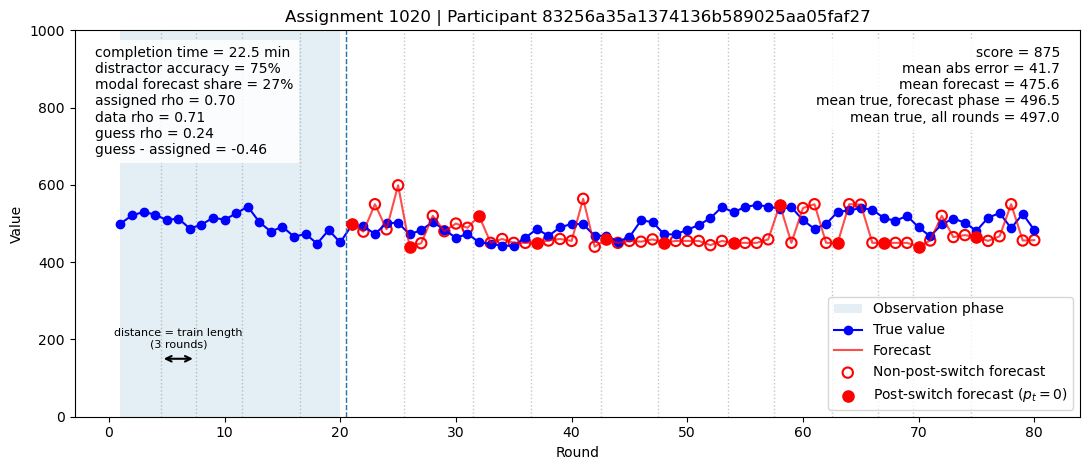

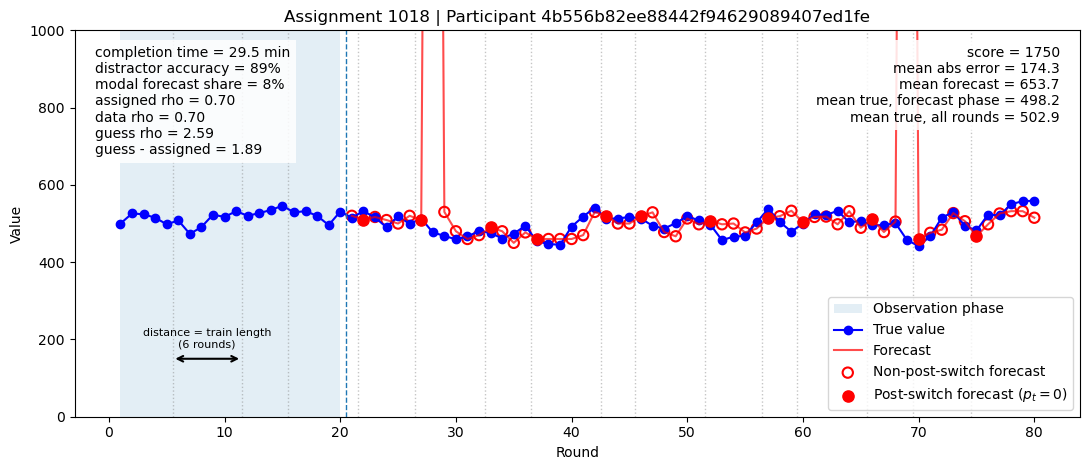

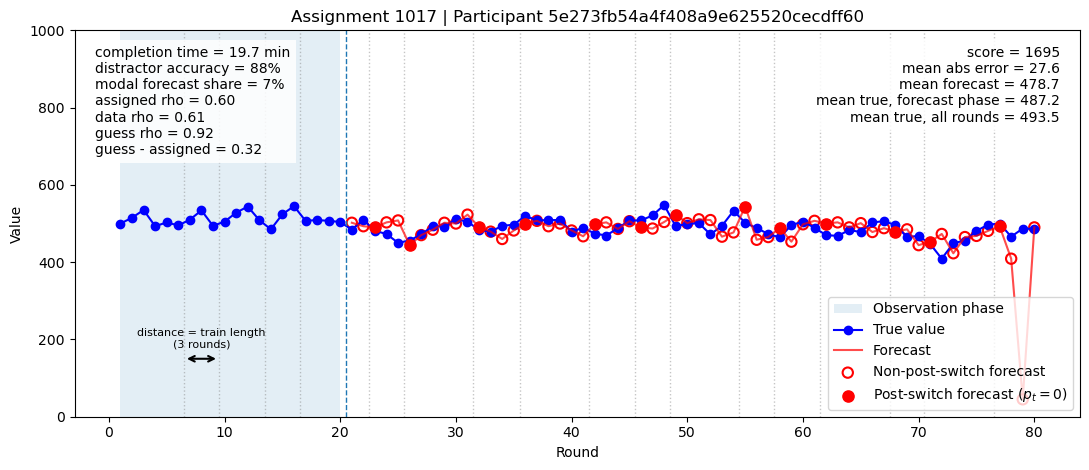

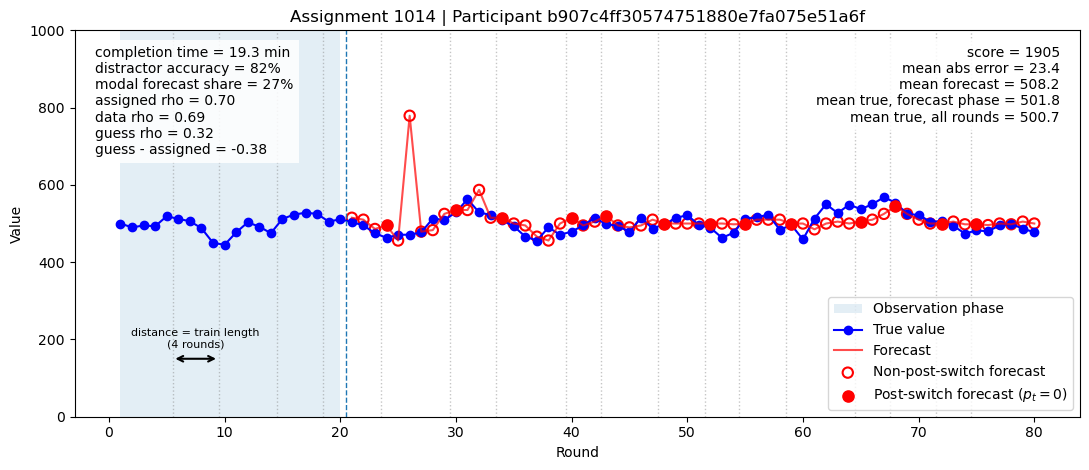

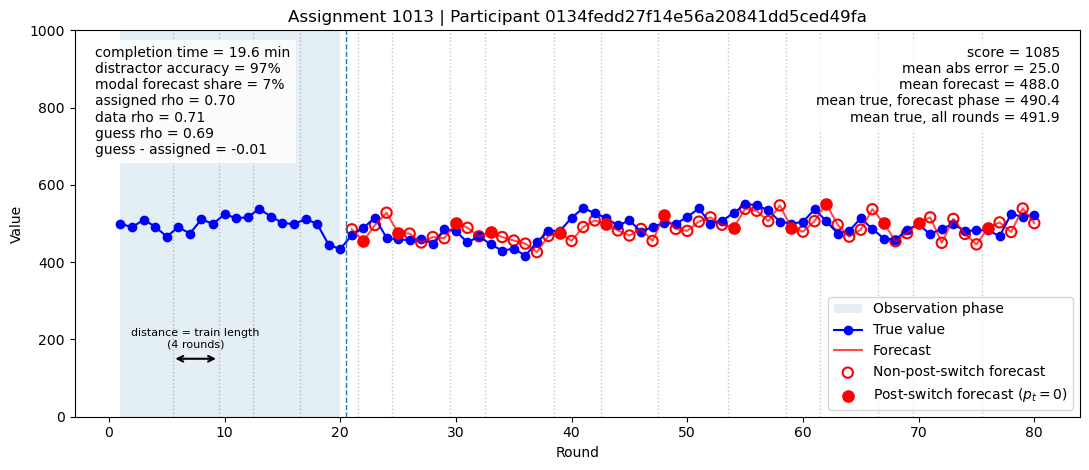

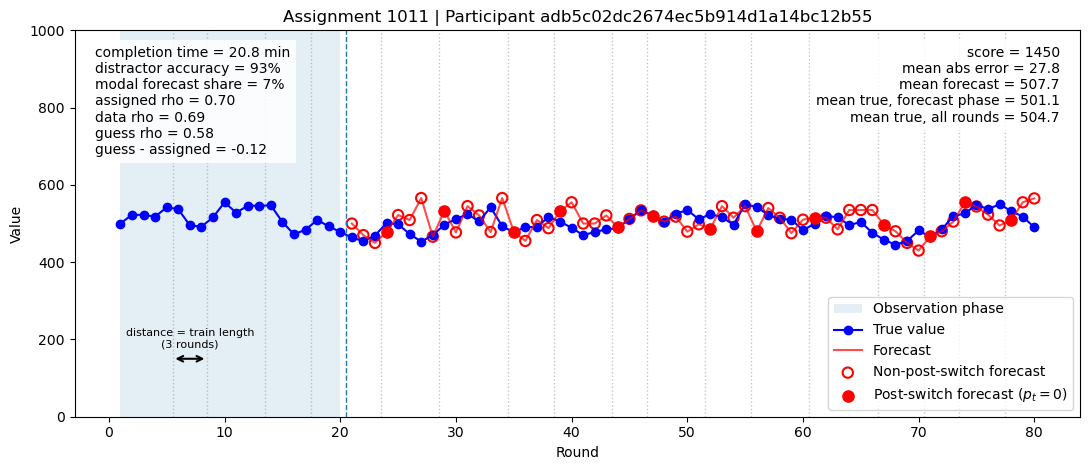

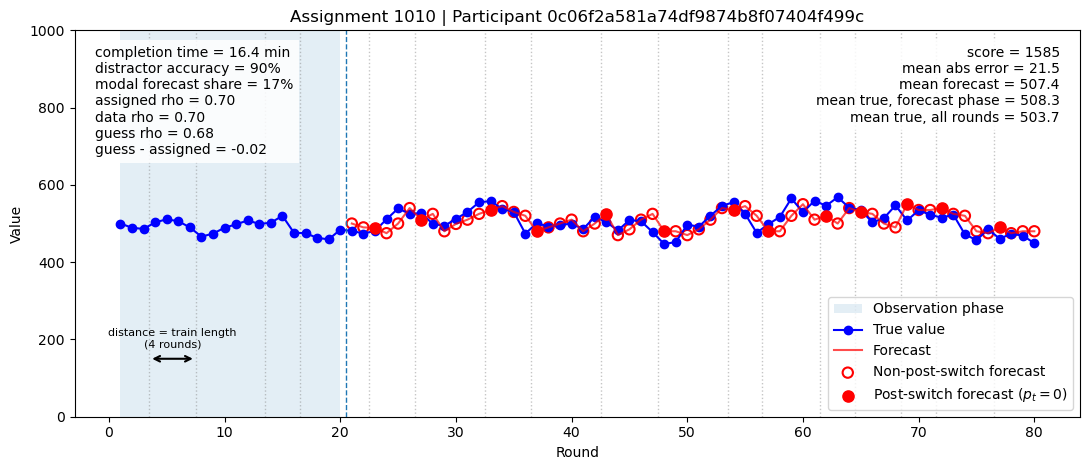

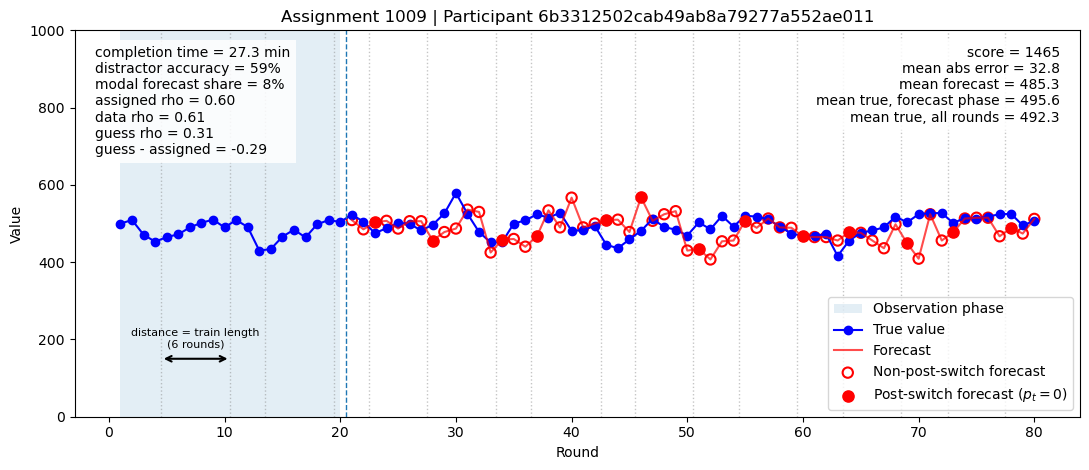

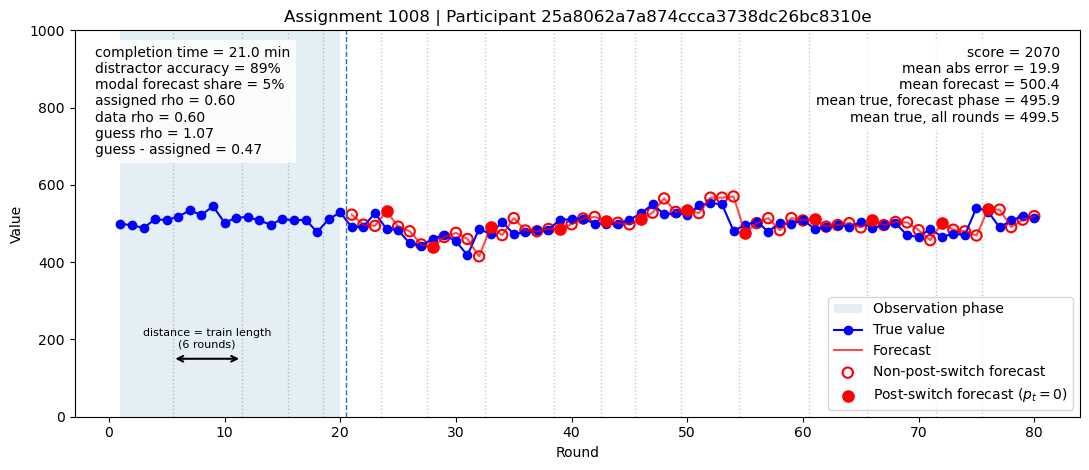

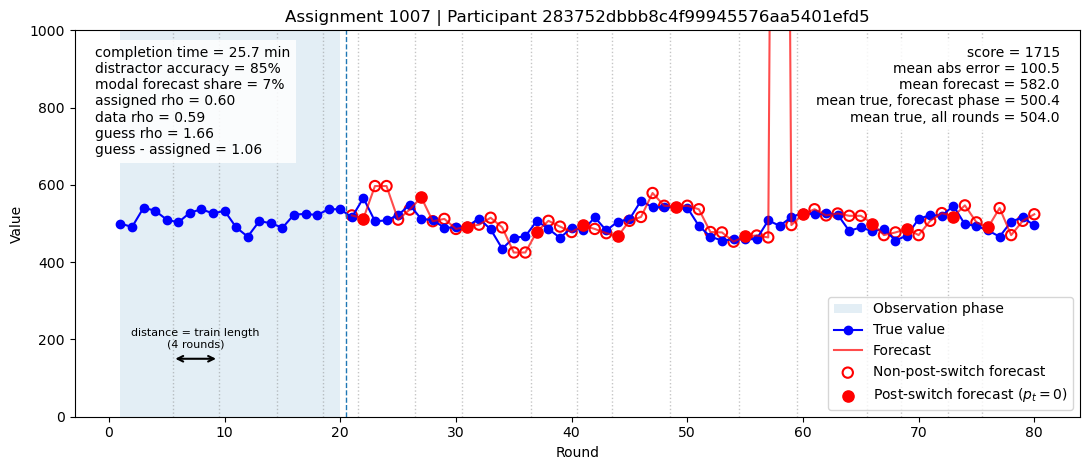

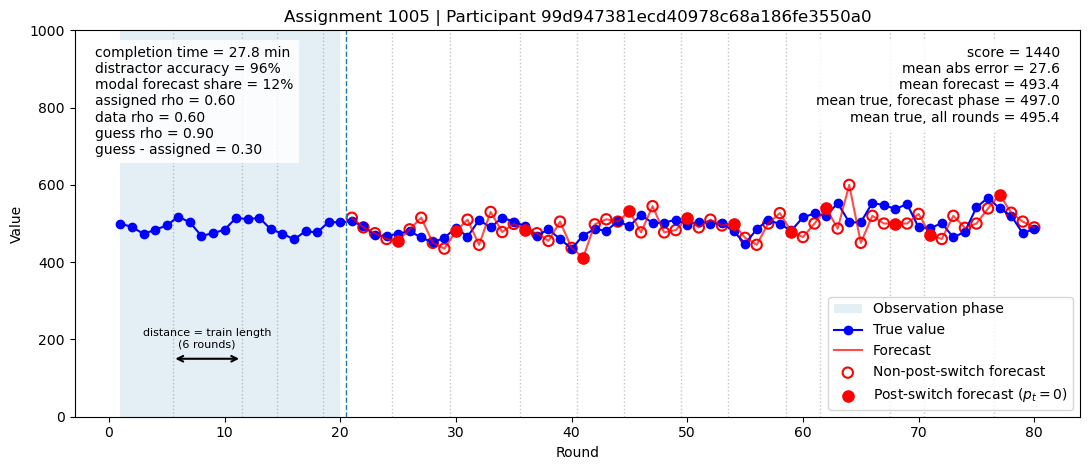

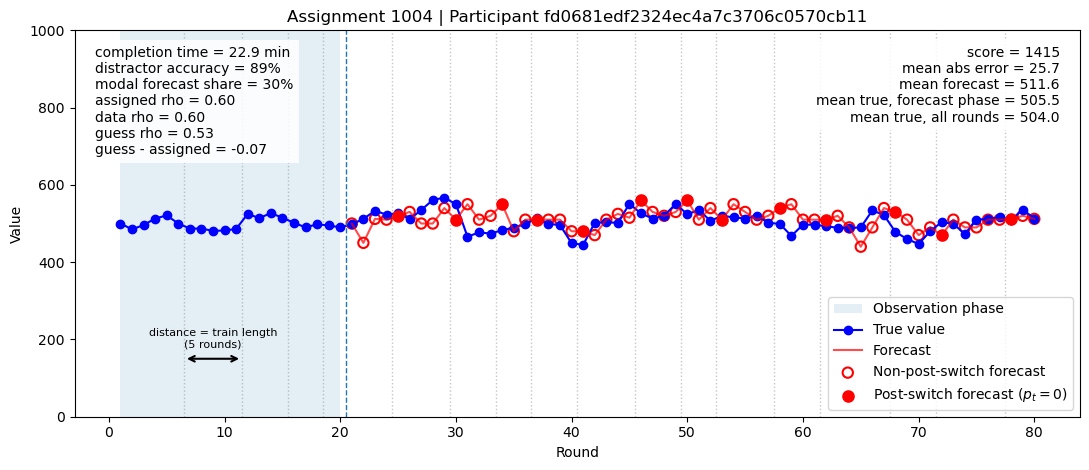

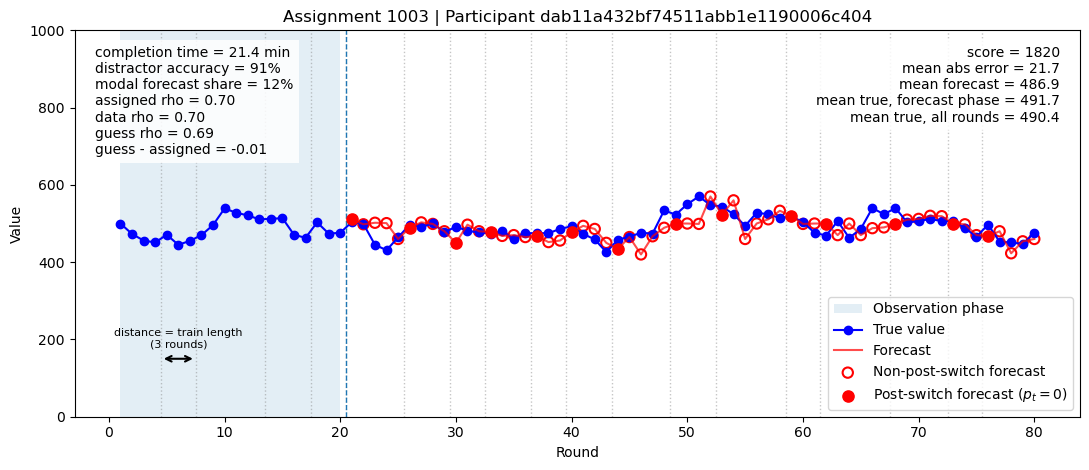

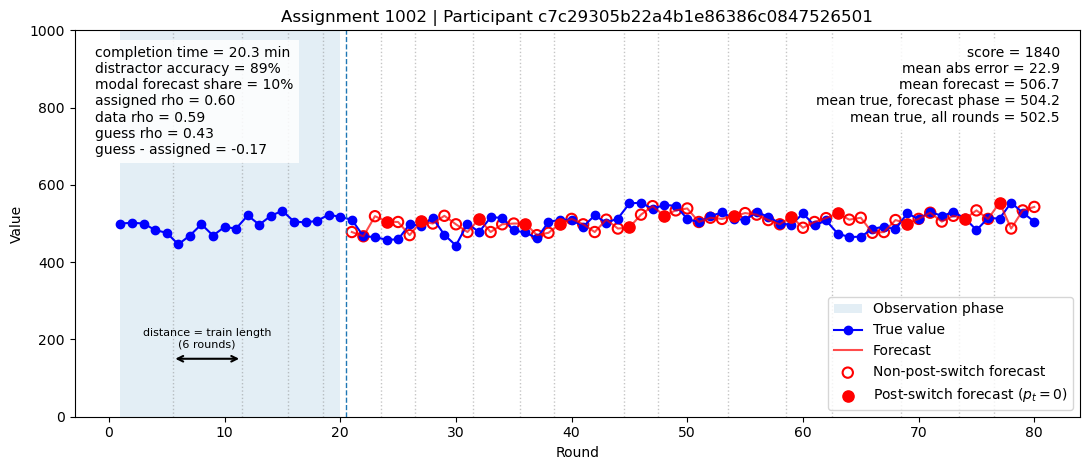

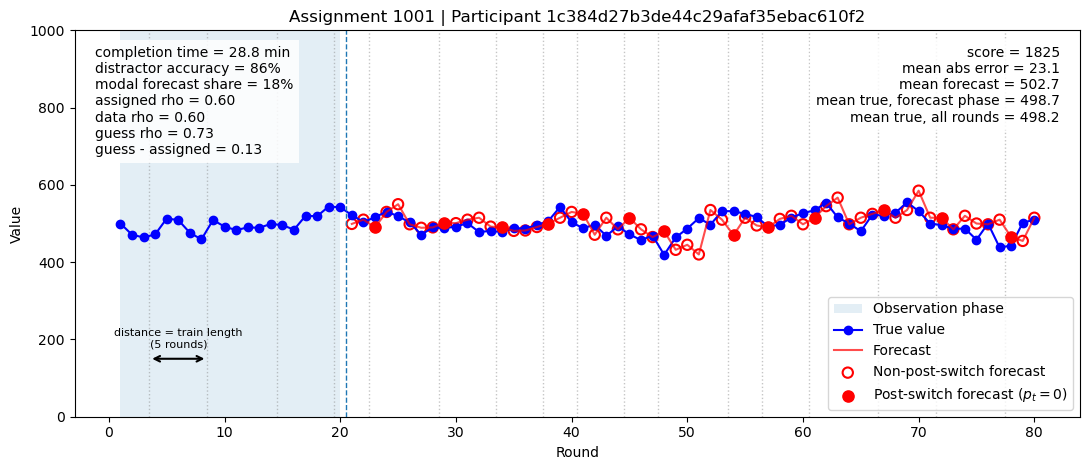

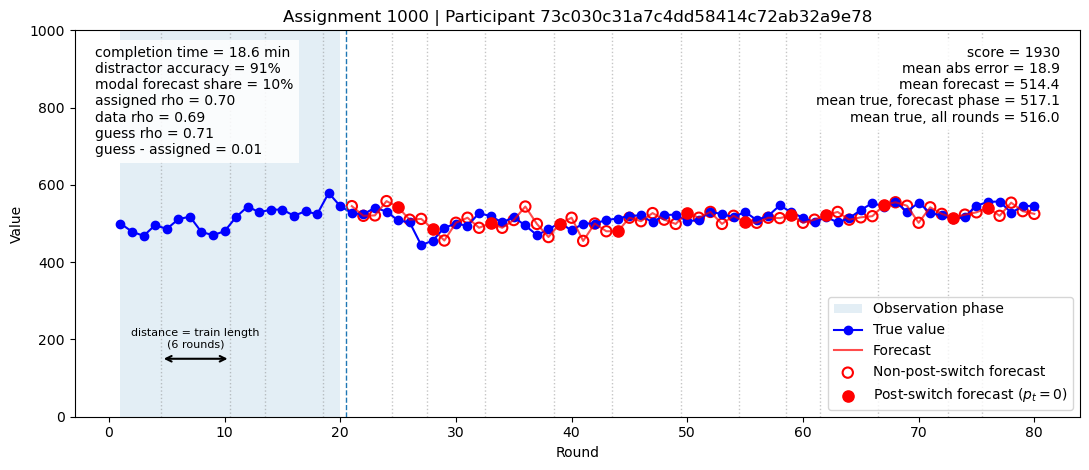

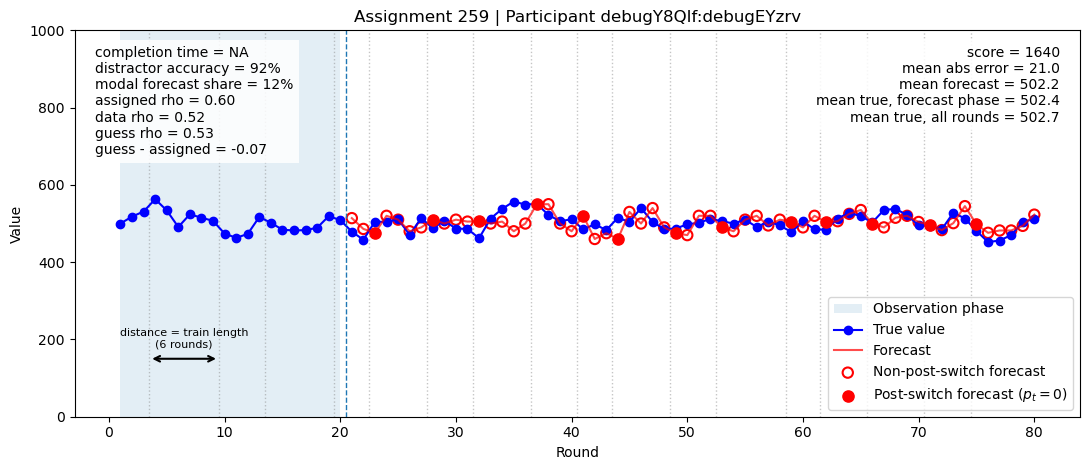

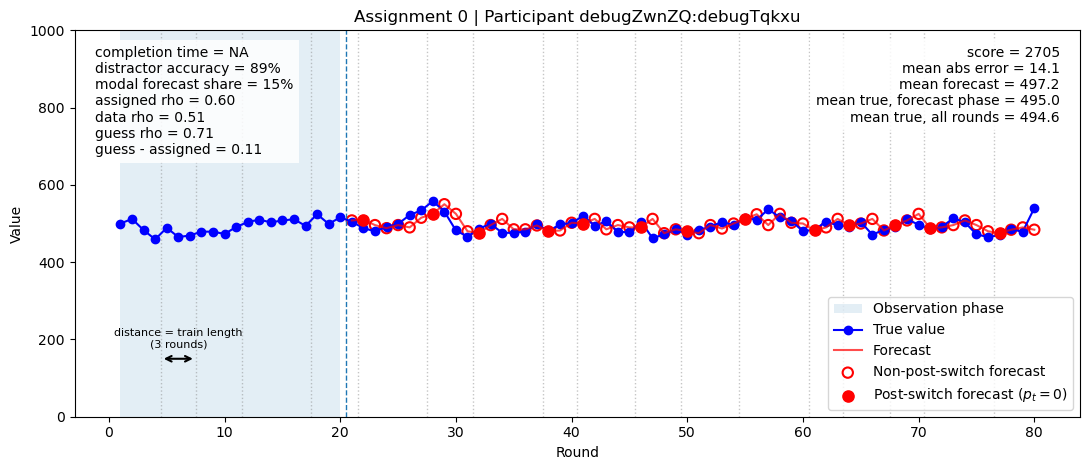

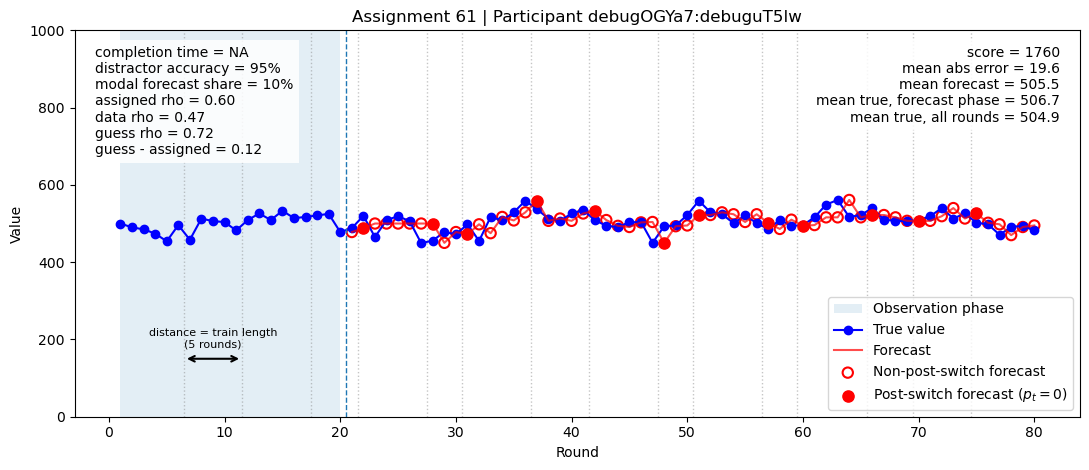

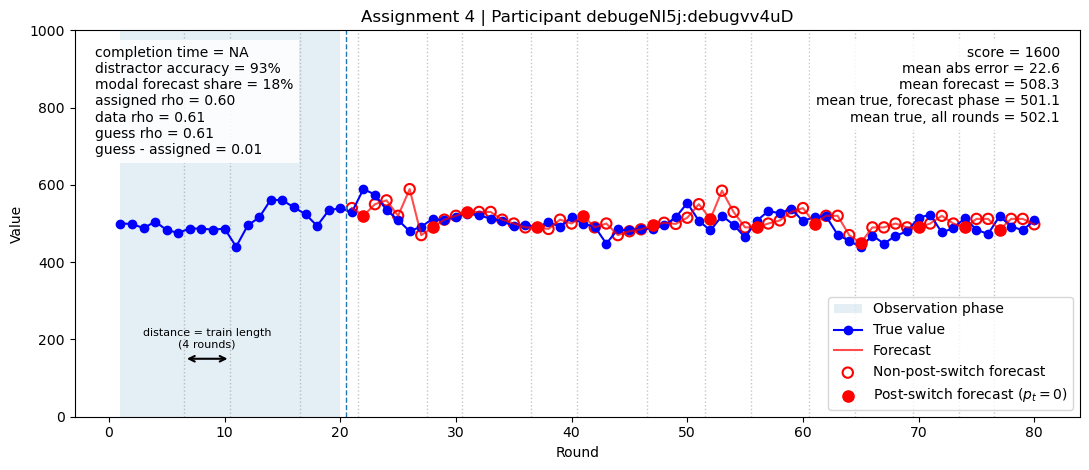

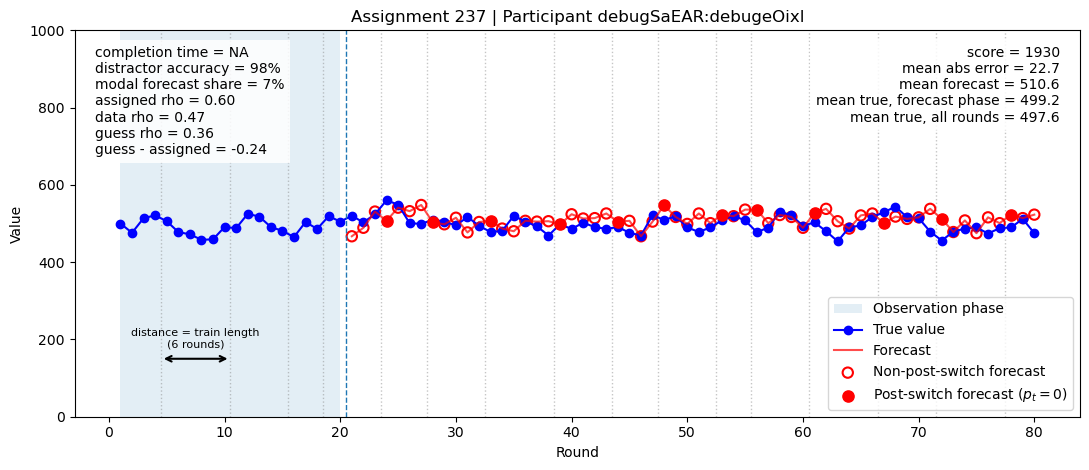

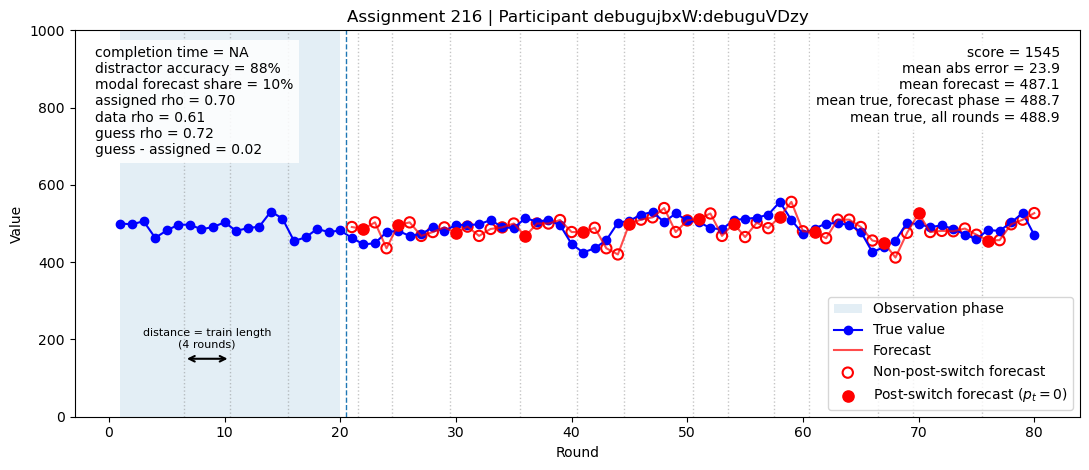

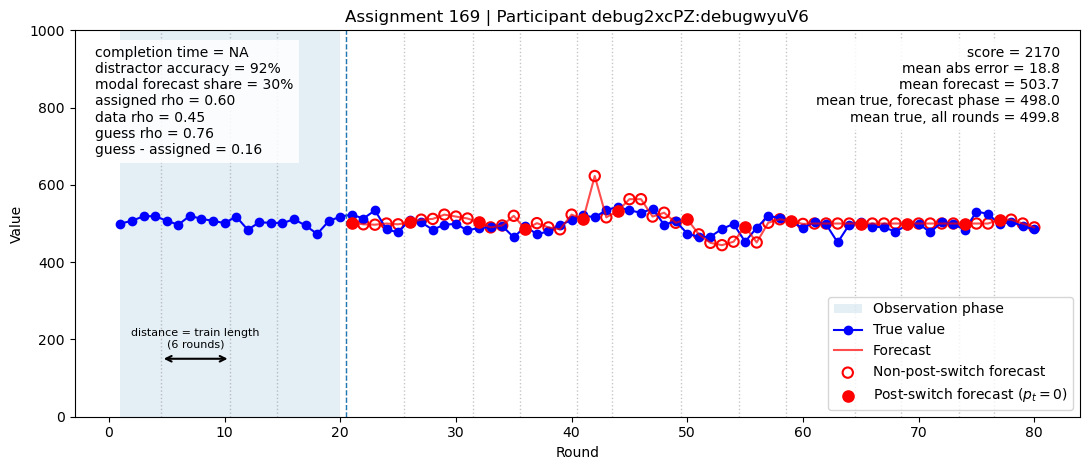

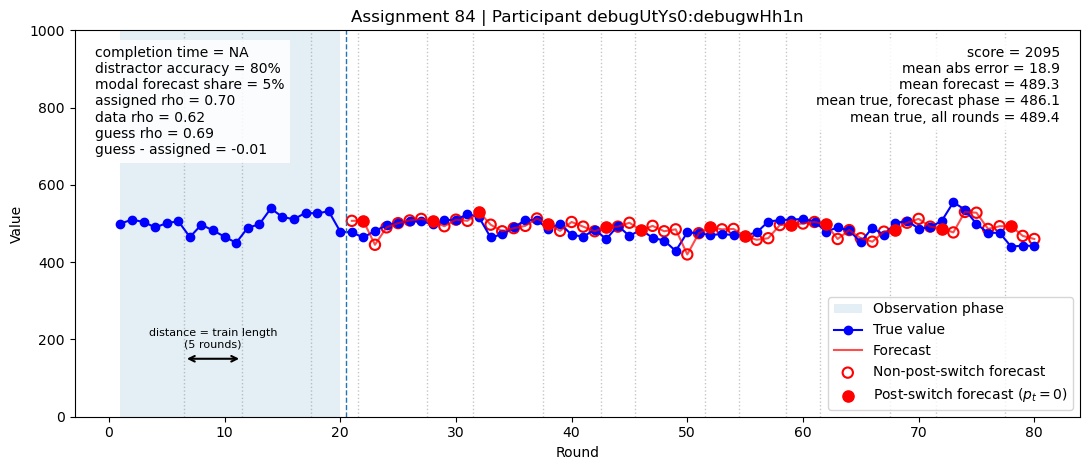

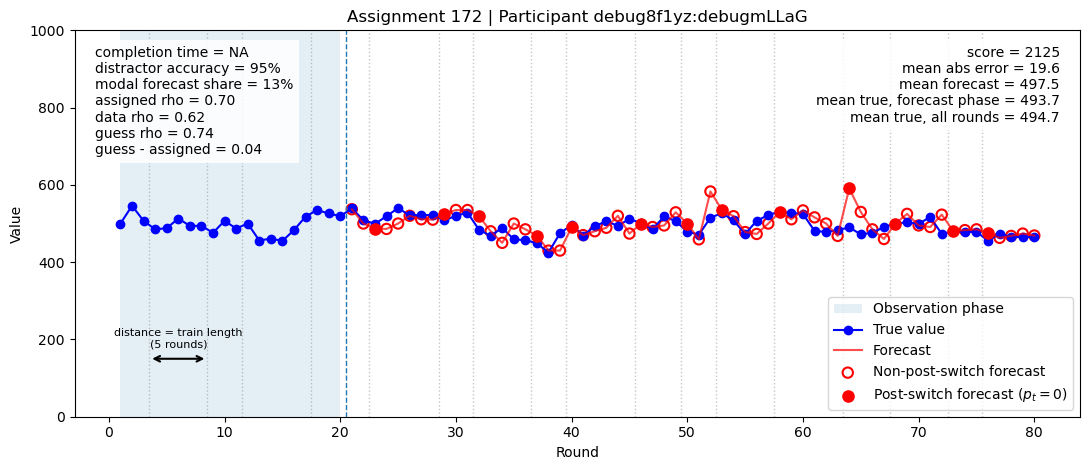

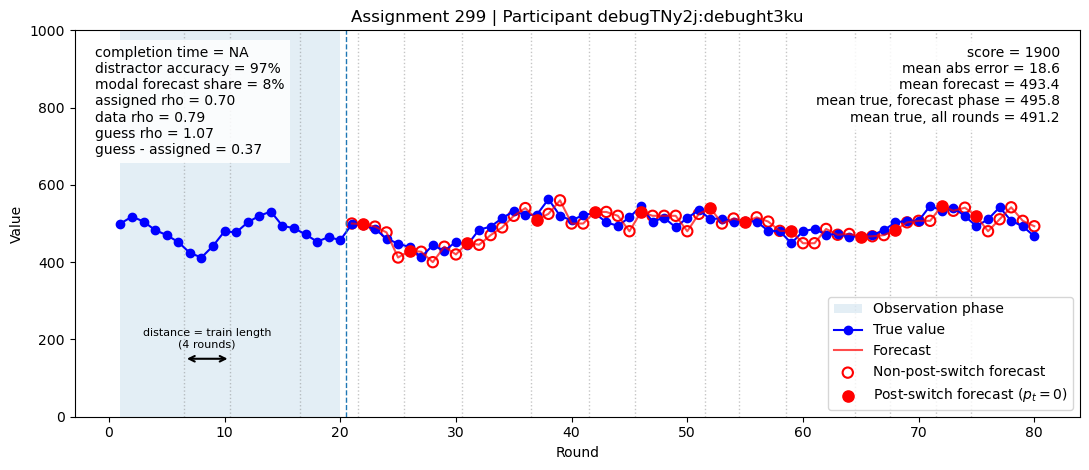

Saved plots for 57 participants to: /Users/oliversmirnov/Documents/GitHub/memory_forecasting_prolific/analysis_outputs/combined_participant_plots


In [22]:
def add_third_train_distance_bracket(ax, g, y=930):
    """
    Add a bracket showing the distance between the first train and third train.

    Assumes:
      - g has display_round, train_id, task_type
      - train_id identifies contiguous task trains
      - the third train is the first return to the task type from train 1
    """

    train_summary = (
        g.dropna(subset=["train_id", "display_round"])
        .groupby("train_id", as_index=False)
        .agg(
            train_start=("display_round", "min"),
            train_end=("display_round", "max"),
            task_type=("task_type", "first"),
            train_length=("display_round", "count"),
        )
        .sort_values("train_start")
        .reset_index(drop=True)
    )

    if len(train_summary) < 3:
        return

    first_train = train_summary.iloc[0]
    second_train = train_summary.iloc[1]
    third_train = train_summary.iloc[2]

    # Optional safety check: third train should match first train's task type
    if third_train["task_type"] != first_train["task_type"]:
        return

    # Bracket spans the intervening train: after train 1, before train 3
    x_left = first_train["train_end"] + 0.5
    x_right = third_train["train_start"] - 0.5

    intervening_length = int(second_train["train_length"])

    ax.annotate(
        "",
        xy=(x_left, y),
        xytext=(x_right, y),
        arrowprops=dict(
            arrowstyle="<->",
            linewidth=1.5,
            color="black"
        )
    )

    ax.text(
        (x_left + x_right) / 2,
        y + 25,
        f"distance = train length\n({intervening_length} rounds)",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black"
    )

for participant_id in recent_participants:
    g = recent_plot_df[
        recent_plot_df[participant_col] == participant_id
    ].copy()

    if g.empty:
        continue

    g = g.sort_values("round_index").copy()

    # Display rounds as 1, 2, ..., 80 instead of 0, 1, ..., 79
    g["display_round"] = g["round_index"] + 1

    assigned_rho = g["assigned_rho"].dropna().iloc[0]
    assignment_slot = int(g["assignment_slot"].dropna().iloc[0])

    final_score = g["final_score"].dropna().max()
    if pd.isna(final_score):
        final_score_text = "NA"
    else:
        final_score_text = f"{final_score:.0f}"

    completion_time = g["completion_time_min"].dropna().max() if "completion_time_min" in g.columns else np.nan
    if pd.isna(completion_time):
        completion_time_text = "NA"
    else:
        completion_time_text = f"{completion_time:.1f} min"

    distractor_accuracy = (
        g["distractor_accuracy"].dropna().max() if "distractor_accuracy" in g.columns else np.nan
    )
    if pd.isna(distractor_accuracy):
        distractor_accuracy_text = "NA"
    else:
        distractor_accuracy_text = f"{distractor_accuracy:.0%}"

    # Data/sample rho using the full true sequence, including observation phase
    data_rho = estimate_slope_from_centered_ols(
        g.dropna(subset=["x_t", "x_next_true"]),
        y_col="x_next_true",
        x_col="x_t"
    )

    # Guess/implied rho using only rows with forecasts
    forecast_rows_for_stats = g.dropna(subset=["forecast_value", "x_t"]).copy()

    guess_rho = estimate_slope_from_centered_ols(
        forecast_rows_for_stats,
        y_col="forecast_value",
        x_col="x_t"
    )

    # Share of forecasts equal to this participant's single most common forecast
    # (computed once, above, alongside the primary-analysis quality filters).
    modal_forecast_share = (
        g["modal_forecast_share"].dropna().max() if "modal_forecast_share" in g.columns else np.nan
    )
    if pd.isna(modal_forecast_share):
        modal_forecast_share_text = "NA"
    else:
        modal_forecast_share_text = f"{modal_forecast_share:.0%}"

    mean_abs_error = np.mean(
        np.abs(
            forecast_rows_for_stats["forecast_value"]
            - forecast_rows_for_stats["x_next_true"]
        )
    )

    mean_forecast = forecast_rows_for_stats["forecast_value"].mean()
    mean_true_forecast_phase = forecast_rows_for_stats["x_next_true"].mean()
    mean_true_all = g["x_next_true"].mean()

    stats_text_left = (
        f"completion time = {completion_time_text}\n"
        f"distractor accuracy = {distractor_accuracy_text}\n"
        f"modal forecast share = {modal_forecast_share_text}\n"
        f"assigned rho = {assigned_rho:.2f}\n"
        f"data rho = {data_rho:.2f}\n"
        f"guess rho = {guess_rho:.2f}\n"
        f"guess - assigned = {guess_rho - assigned_rho:.2f}"
    )

    stats_text_right = (
        f"score = {final_score_text}\n"
        f"mean abs error = {mean_abs_error:.1f}\n"
        f"mean forecast = {mean_forecast:.1f}\n"
        f"mean true, forecast phase = {mean_true_forecast_phase:.1f}\n"
        f"mean true, all rounds = {mean_true_all:.1f}"
    )

    fig, ax = plt.subplots(figsize=(11, 4.8))

    train_boundaries = (
        g[["display_round", "train_id"]]
        .dropna()
        .drop_duplicates()
        .sort_values("display_round")
        .copy()
    )

    train_boundaries["previous_train_id"] = train_boundaries["train_id"].shift(1)

    switch_rounds = train_boundaries.loc[
        train_boundaries["train_id"] != train_boundaries["previous_train_id"],
        "display_round"
    ]

    # Skip the first round, because it is the beginning of the task, not a switch
    switch_rounds = switch_rounds[switch_rounds > 1]

    for switch_round in switch_rounds:
        ax.axvline(
            switch_round - 0.5,
            linestyle=":",
            linewidth=1,
            color="grey",
            alpha=0.45
        )

    # Observation region
    ax.axvspan(
        1,
        FORECAST_START_INDEX,
        alpha=0.12,
        label="Observation phase"
    )

    # True values for all rounds, including observation
    ax.plot(
        g["display_round"],
        g["x_next_true"],
        marker="o",
        color="blue",
        label="True value"
    )

    # Forecast rows
    forecast_rows_for_stats = g.dropna(subset=["forecast_value", "x_t"]).copy()

    post_switch_forecasts = forecast_rows_for_stats[
        forecast_rows_for_stats["p_t"] == 0
    ].copy()

    non_post_switch_forecasts = forecast_rows_for_stats[
        forecast_rows_for_stats["p_t"] != 0
    ].copy()

    # Forecast line across all forecast rounds
    ax.plot(
        forecast_rows_for_stats["display_round"],
        forecast_rows_for_stats["forecast_value"],
        color="red",
        linewidth=1.5,
        alpha=0.70,
        label="Forecast"
    )

    # Non-post-switch forecasts: hollow red circles
    ax.scatter(
        non_post_switch_forecasts["display_round"],
        non_post_switch_forecasts["forecast_value"],
        facecolors="none",
        edgecolors="red",
        s=55,
        marker='o',
        linewidths=1.5,
        label="Non-post-switch forecast"
    )

    # Post-switch forecasts: filled red circles
    ax.scatter(
        post_switch_forecasts["display_round"],
        post_switch_forecasts["forecast_value"],
        color="red",
        s=65,
        marker='o',
        zorder=5,
        label=r"Post-switch forecast $(p_t=0)$"
    )
    
    add_third_train_distance_bracket(ax, g, y=150)

    # Mark transition into forecast phase
    ax.axvline(
        FORECAST_START_INDEX + 0.5,
        linestyle="--",
        linewidth=1
    )


    ax.set_ylim(0, 1000)
    ax.set_xlabel("Round")
    ax.set_ylabel("Value")
    ax.set_title(
        f"Assignment {assignment_slot} | Participant {participant_id}"
    )

    ax.text(
        0.02,
        0.96,
        stats_text_left,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.text(
        0.98,
        0.96,
        stats_text_right,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

    ax.legend(loc="lower right")
    # ax.grid(True, alpha=0.3)

    plt.tight_layout()

    filename = f"assignment_{assignment_slot}_{participant_id}.png"
    safe_filename = (
        filename
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace(" ", "_")
    )

    plt.savefig(OUT_DIR / safe_filename, dpi=150)
    plt.show()

print(f"Saved plots for {len(recent_participants)} participants to: {OUT_DIR}")

In [23]:
baseline_overreaction_table = persistence_tests.copy()

baseline_overreaction_table["stars"] = baseline_overreaction_table[
    "p_value_implied_rho_greater_than_true_rho"
].apply(add_stars)

baseline_overreaction_table["stars_vs_nominal"] = baseline_overreaction_table[
    "p_value_vs_nominal"
].apply(add_stars)

baseline_overreaction_table = baseline_overreaction_table[
    [
        "assigned_rho",
        "n_participants",
        "mean_realized_rho",
        "mean_implied_rho",
        "mean_rho_excess",
        "t_stat",
        "p_value_implied_rho_greater_than_true_rho",
        "stars",
    ]
]

display(Markdown(
    "## 1. Baseline overreaction: implied persistence > realized persistence\n\n"
    "`mean_rho_excess` is implied persistence minus the persistence actually "
    "present in the series each participant saw (`mean_realized_rho`), not "
    "minus the nominal rho."
))

display(format_result_table(baseline_overreaction_table))

display(Markdown(
    "### Robustness: the same test benchmarked against the nominal rho"
))

display(format_result_table(
    persistence_tests[
        [
            "assigned_rho",
            "n_participants",
            "mean_rho_excess_vs_nominal",
            "t_stat_vs_nominal",
            "p_value_vs_nominal",
        ]
    ].assign(
        stars=persistence_tests["p_value_vs_nominal"].apply(add_stars)
    )
))

## 1. Baseline overreaction: implied persistence > realized persistence

`mean_rho_excess` is implied persistence minus the persistence actually present in the series each participant saw (`mean_realized_rho`), not minus the nominal rho.

,assigned_rho,n_participants,mean_realized_rho,mean_implied_rho,mean_rho_excess,t_stat,p_value_implied_rho_greater_than_true_rho,stars
0,0.6,26,0.5781,0.6925,0.1144,1.5100,0.0718,*
1,0.7,21,0.6958,0.7056,0.0099,0.0954,0.4625,


### Robustness: the same test benchmarked against the nominal rho

,assigned_rho,n_participants,mean_rho_excess_vs_nominal,t_stat_vs_nominal,p_value_vs_nominal,stars
0,0.6,26,0.0925,1.2133,0.1182,
1,0.7,21,0.0056,0.0543,0.4786,


In [24]:
postswitch_gamma_table = simple_gamma_postswitch_tests.copy()

postswitch_gamma_table["stars"] = postswitch_gamma_table[
    "p_value_gamma_greater_than_0"
].apply(add_stars)

postswitch_gamma_table = postswitch_gamma_table[
    [
        "assigned_rho",
        "lag_spec",
        "post_switch_positions",
        "n_participants",
        "mean_gamma",
        "median_gamma",
        "t_stat",
        "p_value_gamma_greater_than_0",
        "stars",
    ]
]

display(Markdown("## 2. Post-switch forecast bias: x_match effect, p_t = 0 or 1"))

display(format_result_table(postswitch_gamma_table))

## 2. Post-switch forecast bias: x_match effect, p_t = 0 or 1

,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,t_stat,p_value_gamma_greater_than_0,stars
0,0.6,2,"[0, 1]",26,0.0718,0.0437,0.8226,0.2092,
1,0.6,3,"[0, 1]",26,0.0924,0.0677,0.9988,0.1637,
2,0.7,2,"[0, 1]",21,0.5851,0.1312,1.0719,0.1483,
3,0.7,3,"[0, 1]",21,0.6000,0.0451,1.0871,0.1450,


In [25]:
interaction_gamma_table = interaction_gamma_tests.copy()

interaction_gamma_table["gamma_0_stars"] = interaction_gamma_table[
    "p_value_gamma_0_greater_than_0"
].apply(add_stars)

interaction_gamma_table["gamma_1_stars"] = interaction_gamma_table[
    "p_value_gamma_1_less_than_0"
].apply(add_stars)

interaction_gamma_table = interaction_gamma_table[
    [
        "assigned_rho",
        "lag_spec",
        "n_participants_gamma_0",
        "mean_gamma_0",
        "t_gamma_0",
        "p_value_gamma_0_greater_than_0",
        "gamma_0_stars",
        "mean_gamma_1",
        "t_gamma_1",
        "p_value_gamma_1_less_than_0",
        "gamma_1_stars",
    ]
]

display(Markdown("## 3. Post-switch decay: gamma_0 > 0 and gamma_1 < 0"))

display(format_result_table(interaction_gamma_table))

## 3. Post-switch decay: gamma_0 > 0 and gamma_1 < 0

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,gamma_0_stars,mean_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0,gamma_1_stars
0,0.6,2,26,0.0575,0.5300,0.3004,,0.2589,1.4628,0.9220,
1,0.6,3,26,0.0702,0.6336,0.2660,,0.2560,1.4500,0.9203,
2,0.7,2,21,0.4834,1.0778,0.1470,,-0.0427,-0.7579,0.2287,
3,0.7,3,21,0.5335,1.0679,0.1491,,-0.0689,-0.8388,0.2057,


In [26]:
rho_comparison_table = gamma_condition_postswitch_tests.copy()

rho_comparison_table["stars"] = rho_comparison_table[
    "p_value_rho_07_greater_than_rho_06"
].apply(add_stars)

rho_comparison_table = rho_comparison_table[
    [
        "lag_spec",
        "post_switch_positions",
        "n_rho_06",
        "n_rho_07",
        "mean_gamma_rho_06",
        "mean_gamma_rho_07",
        "difference_07_minus_06",
        "welch_t_stat",
        "p_value_rho_07_greater_than_rho_06",
        "stars",
    ]
]

display(Markdown("## 4. Persistence comparison: post-switch gamma at rho = 0.7 > rho = 0.6"))

display(format_result_table(rho_comparison_table))

## 4. Persistence comparison: post-switch gamma at rho = 0.7 > rho = 0.6

,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,welch_t_stat,p_value_rho_07_greater_than_rho_06,stars
0,2,"[0, 1]",26,21,0.0718,0.5851,0.5133,0.9285,0.1818,
1,3,"[0, 1]",26,21,0.0924,0.6000,0.5077,0.9071,0.1873,


## Robustness check: outlier trains removed, then inaccurate participants excluded

Starting from the primary-analysis sample (`analysis_df_primary`), this check:

1. Flags a forecast as an outlier if its error (`forecast_value - x_next_true`) has an absolute *modified z-score* -- `0.6745 * (error - participant's median error) / participant's MAD` -- greater than `OUTLIER_MODIFIED_Z_THRESHOLD`, and drops the **entire train** it belongs to. This is computed per participant (not pooled across the sample): a pooled mean/SD z-score lets a few genuinely inaccurate participants inflate the SD enough to mask real per-trial errors (e.g. a two-digit typo) in everyone else's data, since the same statistic used to flag extremity is itself skewed by the extremity it is trying to catch. The median/MAD are robust to that -- a couple of bad trials barely move a person's own median or MAD, so their own typos still stand out against their own otherwise-consistent forecasting.
2. Conditional on those trains being removed, recomputes each participant's mean absolute forecast error and drops participants above `MEAN_ABS_ERROR_MAX`.

All three primary analyses are then re-run on this cleaned sample for comparison.

In [27]:
analysis_df_robust_input = analysis_df_primary.copy()

analysis_df_robust_input["forecast_error"] = (
    analysis_df_robust_input["forecast_value"] - analysis_df_robust_input["x_next_true"]
)

def modified_z_scores(errors):
    """Iglewicz & Hoya's modified z-score: robust to the outliers it is
    trying to detect, unlike (error - mean) / sd, whose sd grows with
    exactly the extreme values it should be flagging."""
    median = errors.median()
    mad = (errors - median).abs().median()
    if mad == 0:
        return pd.Series(0.0, index=errors.index)
    return 0.6745 * (errors - median) / mad


analysis_df_robust_input["forecast_error_z"] = (
    analysis_df_robust_input
    .groupby(participant_col)["forecast_error"]
    .transform(modified_z_scores)
)

analysis_df_robust_input["is_outlier_forecast"] = (
    analysis_df_robust_input["forecast_error_z"].abs() > OUTLIER_MODIFIED_Z_THRESHOLD
)

train_outlier_flags = (
    analysis_df_robust_input
    .dropna(subset=[participant_col, "train_id"])
    .groupby([participant_col, "train_id"])["is_outlier_forecast"]
    .any()
    .reset_index(name="train_has_outlier")
)

n_outlier_forecasts = int(analysis_df_robust_input["is_outlier_forecast"].sum())
n_outlier_trains = int(train_outlier_flags["train_has_outlier"].sum())

print(f"Outlier forecasts (|modified z| > {OUTLIER_MODIFIED_Z_THRESHOLD}): {n_outlier_forecasts}")
print(f"Trains eliminated for containing an outlier forecast: {n_outlier_trains} / {len(train_outlier_flags)}")

analysis_df_no_outlier_trains = analysis_df_robust_input.merge(
    train_outlier_flags,
    on=[participant_col, "train_id"],
    how="left"
)

analysis_df_no_outlier_trains = analysis_df_no_outlier_trains[
    ~analysis_df_no_outlier_trains["train_has_outlier"].fillna(False)
].copy()

Outlier forecasts (|z| > 3.0): 4
Trains eliminated for containing an outlier forecast: 4 / 648


In [28]:
participant_mae_robust = (
    analysis_df_no_outlier_trains
    .dropna(subset=[participant_col, "forecast_error"])
    .groupby(participant_col)["forecast_error"]
    .apply(lambda s: s.abs().mean())
    .reset_index(name="mean_abs_error_robust")
)

excluded_inaccurate_participants = set(
    participant_mae_robust.loc[
        participant_mae_robust["mean_abs_error_robust"] > MEAN_ABS_ERROR_MAX,
        participant_col
    ]
)

print(f"Participants excluded for mean abs error (non-outlier trains) > {MEAN_ABS_ERROR_MAX}: {len(excluded_inaccurate_participants)}")

analysis_df_robust = analysis_df_no_outlier_trains[
    ~analysis_df_no_outlier_trains[participant_col].isin(excluded_inaccurate_participants)
].copy()

print(f"Participants remaining in robustness-check sample: {analysis_df_robust[participant_col].nunique()}")

Participants excluded for mean abs error (non-outlier trains) > 30: 7
Participants remaining in robustness-check sample: 40


### 1 (robust). Baseline overreaction

In [29]:
participant_persistence_robust = compute_participant_persistence(
    analysis_df_robust,
    participant_col,
    require_exact_trial_count=False,
)

persistence_tests_robust = test_baseline_overreaction(participant_persistence_robust)

baseline_overreaction_table_robust = persistence_tests_robust.copy()

baseline_overreaction_table_robust["stars"] = baseline_overreaction_table_robust[
    "p_value_implied_rho_greater_than_true_rho"
].apply(add_stars)

baseline_overreaction_table_robust = baseline_overreaction_table_robust[
    [
        "assigned_rho",
        "n_participants",
        "mean_realized_rho",
        "mean_implied_rho",
        "mean_rho_excess",
        "t_stat",
        "p_value_implied_rho_greater_than_true_rho",
        "stars",
    ]
]

display(format_result_table(baseline_overreaction_table_robust))

,assigned_rho,n_participants,mean_realized_rho,mean_implied_rho,mean_rho_excess,t_stat,p_value_implied_rho_greater_than_true_rho,stars
0,0.6,22,0.5741,0.7576,0.1836,4.6353,0.0001,***
1,0.7,18,0.6949,0.6629,-0.0320,-0.8999,0.8096,


### 2 (robust). Post-switch forecast bias

In [30]:
reg_df_robust = prepare_regression_df(analysis_df_robust)

simple_gamma_postswitch_2_robust = participant_level_simple_gamma_postswitch(
    reg_df_robust,
    lag_spec=2,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gamma_postswitch_3_robust = participant_level_simple_gamma_postswitch(
    reg_df_robust,
    lag_spec=3,
    post_switch_positions=POST_SWITCH_POSITIONS
)

simple_gammas_postswitch_robust = pd.concat(
    [simple_gamma_postswitch_2_robust, simple_gamma_postswitch_3_robust],
    ignore_index=True
)

simple_gamma_postswitch_tests_robust = test_postswitch_gamma_greater_than_zero(
    simple_gammas_postswitch_robust
)

postswitch_gamma_table_robust = simple_gamma_postswitch_tests_robust.copy()

postswitch_gamma_table_robust["stars"] = postswitch_gamma_table_robust[
    "p_value_gamma_greater_than_0"
].apply(add_stars)

postswitch_gamma_table_robust = postswitch_gamma_table_robust[
    [
        "assigned_rho",
        "lag_spec",
        "post_switch_positions",
        "n_participants",
        "mean_gamma",
        "median_gamma",
        "t_stat",
        "p_value_gamma_greater_than_0",
        "stars",
    ]
]

display(format_result_table(postswitch_gamma_table_robust))

,assigned_rho,lag_spec,post_switch_positions,n_participants,mean_gamma,median_gamma,t_stat,p_value_gamma_greater_than_0,stars
0,0.6,2,"[0, 1]",22,0.0283,0.0218,0.6363,0.2657,
1,0.6,3,"[0, 1]",22,0.0373,0.0425,0.8228,0.2099,
2,0.7,2,"[0, 1]",18,-0.0294,0.0139,-0.3792,0.6454,
3,0.7,3,"[0, 1]",18,-0.0198,0.0118,-0.2548,0.5990,


### 3 (robust). Reinstatement decay across train position

In [31]:
interaction_gamma_2_robust = participant_level_interaction_gammas(
    reg_df_robust,
    lag_spec=2,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gamma_3_robust = participant_level_interaction_gammas(
    reg_df_robust,
    lag_spec=3,
    include_pt_main_effect=INCLUDE_PT_MAIN_EFFECT
)

interaction_gammas_robust = pd.concat(
    [interaction_gamma_2_robust, interaction_gamma_3_robust],
    ignore_index=True
)

interaction_gamma_tests_robust = test_interaction_gammas(interaction_gammas_robust)

interaction_gamma_table_robust = interaction_gamma_tests_robust.copy()

interaction_gamma_table_robust["gamma_0_stars"] = interaction_gamma_table_robust[
    "p_value_gamma_0_greater_than_0"
].apply(add_stars)

interaction_gamma_table_robust["gamma_1_stars"] = interaction_gamma_table_robust[
    "p_value_gamma_1_less_than_0"
].apply(add_stars)

interaction_gamma_table_robust = interaction_gamma_table_robust[
    [
        "assigned_rho",
        "lag_spec",
        "n_participants_gamma_0",
        "mean_gamma_0",
        "t_gamma_0",
        "p_value_gamma_0_greater_than_0",
        "gamma_0_stars",
        "mean_gamma_1",
        "t_gamma_1",
        "p_value_gamma_1_less_than_0",
        "gamma_1_stars",
    ]
]

display(format_result_table(interaction_gamma_table_robust))

,assigned_rho,lag_spec,n_participants_gamma_0,mean_gamma_0,t_gamma_0,p_value_gamma_0_greater_than_0,gamma_0_stars,mean_gamma_1,t_gamma_1,p_value_gamma_1_less_than_0,gamma_1_stars
0,0.6,2,22,0.0455,0.8466,0.2034,,0.0018,0.0847,0.5334,
1,0.6,3,22,0.0457,0.8464,0.2034,,0.0029,0.1440,0.5565,
2,0.7,2,18,-0.0333,-0.3679,0.6413,,0.0208,0.7081,0.7558,
3,0.7,3,18,-0.0335,-0.3718,0.6427,,0.0214,0.7337,0.7634,


### 4 (robust). Persistence comparison: rho 0.7 vs rho 0.6

In [32]:
gamma_condition_postswitch_tests_robust = test_gamma_condition_comparison(
    simple_gammas_postswitch_robust
)

rho_comparison_table_robust = gamma_condition_postswitch_tests_robust.copy()

rho_comparison_table_robust["stars"] = rho_comparison_table_robust[
    "p_value_rho_07_greater_than_rho_06"
].apply(add_stars)

rho_comparison_table_robust = rho_comparison_table_robust[
    [
        "lag_spec",
        "post_switch_positions",
        "n_rho_06",
        "n_rho_07",
        "mean_gamma_rho_06",
        "mean_gamma_rho_07",
        "difference_07_minus_06",
        "welch_t_stat",
        "p_value_rho_07_greater_than_rho_06",
        "stars",
    ]
]

display(format_result_table(rho_comparison_table_robust))

,lag_spec,post_switch_positions,n_rho_06,n_rho_07,mean_gamma_rho_06,mean_gamma_rho_07,difference_07_minus_06,welch_t_stat,p_value_rho_07_greater_than_rho_06,stars
0,2,"[0, 1]",22,18,0.0283,-0.0294,-0.0578,-0.6456,0.7381,
1,3,"[0, 1]",22,18,0.0373,-0.0198,-0.0571,-0.6343,0.7345,
